# Representation Learning and Sequence Modeling in High-Dimensional Data


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

GDP_DIR = Path(".").resolve()
DATA_FILENAME = "data.csv"
DATA_PATH = GDP_DIR / DATA_FILENAME


## Data Generating Process Hypothesis

In this case study, each customer's behavior is observed only through **transactional line items** (invoices, items, quantities, prices, timestamps). I treat future purchase-related outcomes as generated by an underlying process that depends on **how recently and how often** the customer shops, **how much they spend**, **how concentrated or diverse** their basket is, and **temporal patterns**, plus unobserved shocks:

`future_behavior ≈ g(recency, frequency, spend_level, basket_diversity, temporal_patterns, context) + ε`

Feature Engineered columns:

- **`n_invoices`** and **`mean_interpurchase_days`** proxy purchase frequency and cadence between orders.
- **`total_spend`** and **`avg_invoice_value`** proxy monetary propensity and typical basket value per invoice.
- **`recency_days`** measures how recently the customer was active relative to the latest transaction date in the dataset.
- **`item_diversity_ratio`** measures whether purchases are spread across many distinct products or concentrated in a few.

The noise term **ε** aggregates factors not fully summarized by these features, such as promotions, stock availability, pricing changes, one-off bulk orders, and idiosyncratic shopping motives.

Important **omitted variables** likely affect behavior but are not explicit columns here (e.g. marketing exposure, competitor prices, demographics, product substitution beyond coarse stock codes).

There is also **coverage and selection bias**: many rows lack `CustomerID`; the modeling stream uses **positive purchase** transactions after cleaning returns/cancellations and invalid economics. Conclusions describe **observed transactional behavior under these constraints**, not universal consumer behavior.

I will use EDA, unsupervised structure discovery, and  supervised models to probe how well summaries of `g(·)` support prediction and whether richer sequence representations add value.

## 1) Load Raw Data and Validate Canonical Schema

In [2]:
RAW_SCHEMA = {
    "InvoiceNo": "string",
    "StockCode": "string",
    "Description": "string",
    "Quantity": "Int64",
    "InvoiceDate": "string",
    "UnitPrice": "float64",
    "CustomerID": "string",
    "Country": "string",
}

required_columns = list(RAW_SCHEMA.keys())

try:
    df_raw = pd.read_csv(DATA_PATH, encoding="utf-8")
    used_encoding = "utf-8"
except UnicodeDecodeError:
    df_raw = pd.read_csv(DATA_PATH, encoding="latin1")
    used_encoding = "latin1"

missing_cols = [c for c in required_columns if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f"Dataset is missing required columns: {missing_cols}")

for c, dtype in RAW_SCHEMA.items():
    if c == "InvoiceDate":
        continue
    if c in df_raw.columns:
        try:
            df_raw[c] = df_raw[c].astype(dtype)
        except Exception:
            pass

print("Raw shape:", df_raw.shape)
display(df_raw.head())

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


The dataset has 541,909 rows with 8 columns including InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country

## 1.5) Column Quality Check


In [3]:
quality = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing_count": df_raw.isna().sum(),
    "missing_pct": (df_raw.isna().mean() * 100).round(2),
    "n_unique": df_raw.nunique(dropna=True),
})

quality.loc["CustomerID", "blank_like_count"] = int(
    df_raw["CustomerID"].astype("string").str.strip().isin(["", "<NA>", "nan", "None"]).sum()
)
quality.loc["InvoiceDate", "unparseable_count"] = int(
    pd.to_datetime(df_raw["InvoiceDate"], errors="coerce", utc=True).isna().sum()
)
quality.loc["Quantity", "nonpositive_count"] = int((pd.to_numeric(df_raw["Quantity"], errors="coerce") <= 0).sum())
quality.loc["UnitPrice", "nonpositive_count"] = int((pd.to_numeric(df_raw["UnitPrice"], errors="coerce") <= 0).sum())
quality.loc["InvoiceNo", "cancel_prefix_count"] = int(
    df_raw["InvoiceNo"].astype("string").str.startswith("C", na=False).sum()
)

canonical_cols = ["InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID", "Country"]
raw_dupes = int(df_raw.duplicated(subset=canonical_cols).sum())

print(f"Raw exact duplicates on canonical columns: {raw_dupes:,}")

quality_display = quality.copy()
quality_display = quality_display.fillna("-")
display(quality_display)


Raw exact duplicates on canonical columns: 5,268


,dtype,missing_count,missing_pct,n_unique,blank_like_count,unparseable_count,nonpositive_count,cancel_prefix_count
InvoiceNo,string,0,0.00,25900,-,-,-,9288.0
StockCode,string,0,0.00,4070,-,-,-,-
Description,string,1454,0.27,4223,-,-,-,-
Quantity,Int64,0,0.00,722,-,-,10624.0,-
InvoiceDate,str,0,0.00,23260,-,0.0,-,-
UnitPrice,float64,0,0.00,1630,-,-,2517.0,-
CustomerID,string,135080,24.93,4372,0.0,-,-,-
Country,string,0,0.00,38,-,-,-,-


Quality checks on 541,909 records identified 5,268 exact duplicate transaction rows and substantial identifier missingness (24.93% missing CustomerID, 135,080 rows), which materially affects customer-level sequence construction. Timestamp integrity was high (0 unparseable InvoiceDate values). Return/cancellation behavior was non-trivial (9,288 cancellation-marked invoices; 10,624 non-positive quantities), and 2,517 rows had non-positive prices. Accordingly, I deduplicated records and restricted the purchase modeling stream to customer-identified, positive-quantity, positive-price, non-cancellation transactions, while retaining auditable flags in the cleaned table.”

## 2) Cleaning 

Policies implemented:
- Drop rows with missing `CustomerID` and convert to Integer
- Normalize `StockCode, InvoiceNo, Country, Description`
- Remove exact duplicates
- Tag cancellations and returns

Pipeline roadmap used throughout the notebook:
- `df_raw` -> original loaded dataset
- `transactions_clean` -> cleaned transactions with audit flags
- `transactions_purchase` -> purchase-only transaction stream for behavior modeling
- `customer_events` -> feature-engineered event table derived from `transactions_purchase`
- `customer_features_base` -> customer-level aggregated table (one row per customer)


In [4]:
df = df_raw.copy()

# Normalize fields
for col in ["InvoiceNo", "StockCode", "Country", "Description"]:
    df[col] = df[col].astype("string").str.strip()

# Normalize CustomerID to nullable integer IDs.
df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce").astype("Int64")

# Parse timestamps (no date-row cleaning applied)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce", utc=True).dt.tz_localize(None)

# Tag cancellation/return behavior
df["is_cancel_invoice"] = df["InvoiceNo"].str.startswith("C", na=False)
df["is_return_qty"] = df["Quantity"].fillna(0) <= 0
df["is_nonpositive_price"] = df["UnitPrice"].fillna(0) <= 0

# Retention checkpoints
retention = []
def checkpoint(name, frame):
    retention.append({
        "step": name,
        "rows": int(len(frame)),
        "unique_customers": int(frame["CustomerID"].nunique(dropna=True)),
    })

checkpoint("raw", df)

# Drop missing CustomerID
df = df[df["CustomerID"].notna()].copy()
checkpoint("after_customerid_filter", df)

# Remove exact duplicates on canonical fields
canonical_cols = [
    "InvoiceNo", "StockCode", "Description", "Quantity", "InvoiceDate", "UnitPrice", "CustomerID", "Country"
]
df = df.drop_duplicates(subset=canonical_cols).copy()
checkpoint("after_dedup", df)

# transactions_clean (auditable cleaned lines)
transactions_clean = df.copy()
transactions_clean["LineAmount"] = transactions_clean["Quantity"].astype(float) * transactions_clean["UnitPrice"].astype(float)

# purchase-only stream for baseline behavior modeling
transactions_purchase = transactions_clean[
    (~transactions_clean["is_cancel_invoice"])
    & (transactions_clean["Quantity"] > 0)
    & (transactions_clean["UnitPrice"] > 0)
].copy()
checkpoint("purchase_stream", transactions_purchase)

retention_df = pd.DataFrame(retention)
display(retention_df)
display(
    pd.DataFrame(
        {
            "dataset": ["transactions_clean", "transactions_purchase"],
            "shape": [str(transactions_clean.shape), str(transactions_purchase.shape)],
        }
    )
)

,step,rows,unique_customers
0,raw,541909,4372
1,after_customerid_filter,406829,4372
2,after_dedup,401604,4372
3,purchase_stream,392692,4338


,dataset,shape
0,transactions_clean,"(401604, 12)"
1,transactions_purchase,"(392692, 12)"


The dataset initially contained 541,909 transactions across 4,372 unique customers (non-null CustomerID). I first removed rows with missing CustomerID (135,080 rows), reducing the dataset to 406,829 transactions while keeping 4,372 identifiable customers. Next, I removed 5,225 exact duplicate rows (across canonical transaction fields) to reduce double-entry noise. I then restricted the modeling stream to valid positive purchases (Quantity > 0, UnitPrice > 0, and non-cancellation invoices), resulting in 392,692 transactions. I kept two datasets for analysis: transactions_clean (auditable cleaned data including return/cancellation flags) and transactions_purchase (purchase-only stream for behavior modeling).

## Feature Engineering



In [5]:
customer_events = transactions_purchase[[
    "CustomerID", "InvoiceDate", "InvoiceNo", "StockCode", "Quantity", "UnitPrice", "LineAmount", "Country"
]].copy()

# Add row-level engineered columns directly on transactions_purchase track
customer_events["invoice_day"] = customer_events["InvoiceDate"].dt.floor("D")
customer_events["hour"] = customer_events["InvoiceDate"].dt.hour
customer_events["weekday"] = customer_events["InvoiceDate"].dt.dayofweek
customer_events["month"] = customer_events["InvoiceDate"].dt.to_period("M").dt.to_timestamp()

invoice_level = (
    customer_events.groupby(["CustomerID", "InvoiceNo", "invoice_day"], as_index=False)
    .agg(invoice_value=("LineAmount", "sum"))
    .sort_values(["CustomerID", "invoice_day", "InvoiceNo"])
)

invoice_level["prev_day"] = invoice_level.groupby("CustomerID")["invoice_day"].shift(1)
invoice_level["interpurchase_days"] = (invoice_level["invoice_day"] - invoice_level["prev_day"]).dt.days

invoice_stats = invoice_level.groupby("CustomerID", as_index=False).agg(
    n_invoices=("InvoiceNo", "nunique"),
    avg_invoice_value=("invoice_value", "mean"),
    mean_interpurchase_days=("interpurchase_days", "mean"),
)

# Customer-level aggregates
customer_base = customer_events.groupby("CustomerID", as_index=False).agg(
    n_line_items=("StockCode", "count"),
    n_unique_items=("StockCode", "nunique"),
    total_spend=("LineAmount", "sum"),
    first_purchase=("InvoiceDate", "min"),
    last_purchase=("InvoiceDate", "max"),
)

customer_features_base = customer_base.merge(invoice_stats, on="CustomerID", how="left")

max_date = customer_events["InvoiceDate"].max()
customer_features_base["recency_days"] = (max_date - customer_features_base["last_purchase"]).dt.days
customer_features_base["item_diversity_ratio"] = (
    customer_features_base["n_unique_items"] / customer_features_base["avg_invoice_value"].clip(lower=1)
)

feature_cols = [
    "CustomerID",
    "n_invoices",
    "total_spend",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]

customer_events = customer_events.merge(
    customer_features_base[feature_cols],
    on="CustomerID",
    how="left",
)

customer_features_base = customer_features_base[feature_cols].copy()
num_feature_cols = [
    "n_invoices",
    "total_spend",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]
customer_features_base[num_feature_cols] = customer_features_base[num_feature_cols].apply(pd.to_numeric, errors="coerce")
customer_features_base[num_feature_cols] = customer_features_base[num_feature_cols].fillna(
    customer_features_base[num_feature_cols].median(numeric_only=True)
)

customer_features_base.head()


,CustomerID,n_invoices,total_spend,avg_invoice_value,recency_days,mean_interpurchase_days,item_diversity_ratio
0,12346,1,77183.60,77183.600000,325,53.500000,0.000013
1,12347,7,4310.00,615.714286,1,60.833333,0.167285
2,12348,4,1797.24,449.310000,74,94.333333,0.048964
3,12349,1,1757.55,1757.550000,18,53.500000,0.041535
4,12350,1,334.40,334.400000,309,53.500000,0.050837


The customer-level feature engineering:

- `n_invoices`: number of invoices per customer.
- `total_spend`: total monetary value spent by the customer across purchases.
- `avg_invoice_value`: average invoice amount for the customer.
- `recency_days`: number of days between the dataset's latest invoice date and the customer's last purchase date.
- `mean_interpurchase_days`: average number of days between consecutive purchases (NaN for one-time buyers).
- `item_diversity_ratio`: unique items purchased divided by total line items purchased by the customer, the higher the ration the more unique items the customer bought

The results show distinct customer behaviors. Customer 12346 spent 77,183.60 on just 1 invoice, with the last purchase occurring about 325 days before the dataset’s latest date, indicating high monetary value but very low purchase frequency. Customer 12347 spent 4,310.00 across 7 invoices, with a recency of 1 day, indicating frequent and recent engagement. The diversity ratio for customer 12347 is o.167 which is higher than for customer 12346, suggesting repeated purchases of some items rather than entirely unique products each time. Overall, customer 12346 appears to be a one-time high-value buyer, while customer 12347 reflects a more consistent repeat-purchase profile.

## 4) Exploratory Data Analysis (EDA)


,count,mean,std,min,25%,50%,75%,max
CustomerID,392692.0,15287.843865,1713.539549,12346.0,13955.0,15150.0,16791.0,18287.0
Quantity,392692.0,13.119702,180.492832,1.0,2.0,6.0,12.0,80995.0
UnitPrice,392692.0,3.125914,22.241836,0.001,1.25,1.95,3.75,8142.75
LineAmount,392692.0,22.6315,311.099224,0.001,4.95,12.45,19.8,168469.6
hour,392692.0,12.721532,2.276661,6.0,11.0,13.0,14.0,20.0
weekday,392692.0,2.606911,1.923929,0.0,1.0,2.0,4.0,6.0
n_invoices,392692.0,18.786285,37.293191,1.0,3.0,7.0,15.0,209.0
total_spend,392692.0,11565.753316,31431.816122,3.75,1097.62,2662.06,6287.77,280206.02
avg_invoice_value,392692.0,554.251731,750.045609,3.45,234.85,360.366154,572.762857,84236.25
recency_days,392692.0,40.11291,65.402913,0.0,3.0,15.0,42.0,373.0


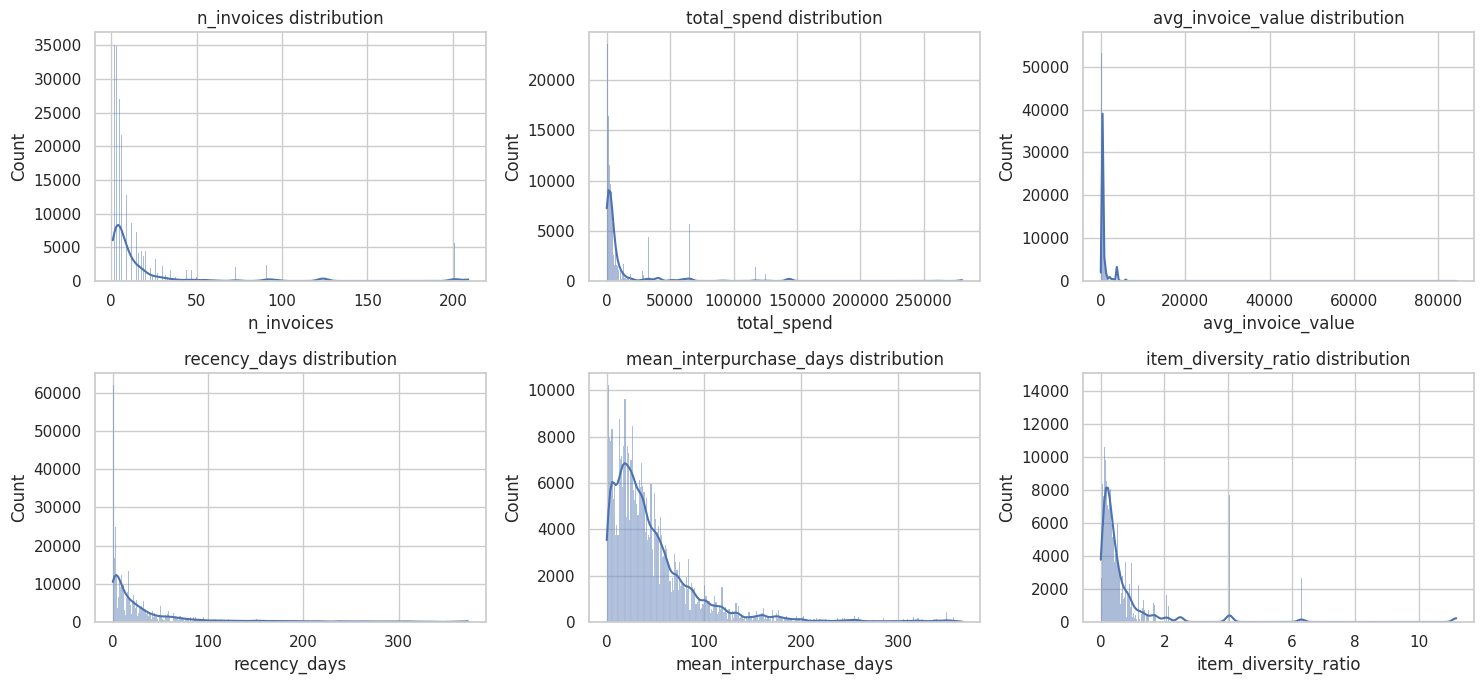

In [6]:
main_df = customer_events.copy()

num_features = [col for col in main_df.columns if pd.api.types.is_numeric_dtype(main_df[col])]
summary = main_df[num_features].describe().T
display(summary)

# Raw-scale marginal distributions for selected engineered features
focus_features = [
    "n_invoices",
    "total_spend",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]
plot_features = [c for c in focus_features if c in main_df.columns]

n_cols = 3
n_rows = int(np.ceil(len(plot_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_features):
    vals = pd.to_numeric(main_df[col], errors="coerce").dropna()
    sns.histplot(vals, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} distribution")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

The purchase stream is highly right-skewed across economic variables. Quantity shows long-tail purchase sizes (median 6 vs extreme maximum 80,995). UnitPrice is similarly skewed (0.001 to 8,142.75 with low central tendency relative to the upper tail). Monetary outcomes (LineAmount/total_spend) are dominated by a small number of high-value observations, indicating strong heterogeneity and outlier sensitivity

# Marginal Distribution

,count,mean,std,min,50%,75%,90%,95%,99%,max
n_invoices,4338.0,4.272015,7.697998,1.000000,2.000000,5.000000,9.000000,13.00000,30.000000,209.000000
total_spend,4338.0,2048.688081,8985.230220,3.750000,668.570000,1660.597500,3640.841000,5789.99950,19780.487800,280206.020000
avg_invoice_value,4338.0,417.645735,1796.511343,3.450000,291.940000,428.280625,659.735167,936.33200,2031.161200,84236.250000
recency_days,4338.0,91.536422,100.014169,0.000000,50.000000,141.000000,262.000000,311.00000,368.000000,373.000000
mean_interpurchase_days,4338.0,66.061763,53.866811,0.000000,53.500000,68.475000,124.000000,177.07500,306.000000,366.000000
item_diversity_ratio,4338.0,0.206352,0.326755,0.000013,0.120136,0.245767,0.457798,0.63932,1.309315,11.179314


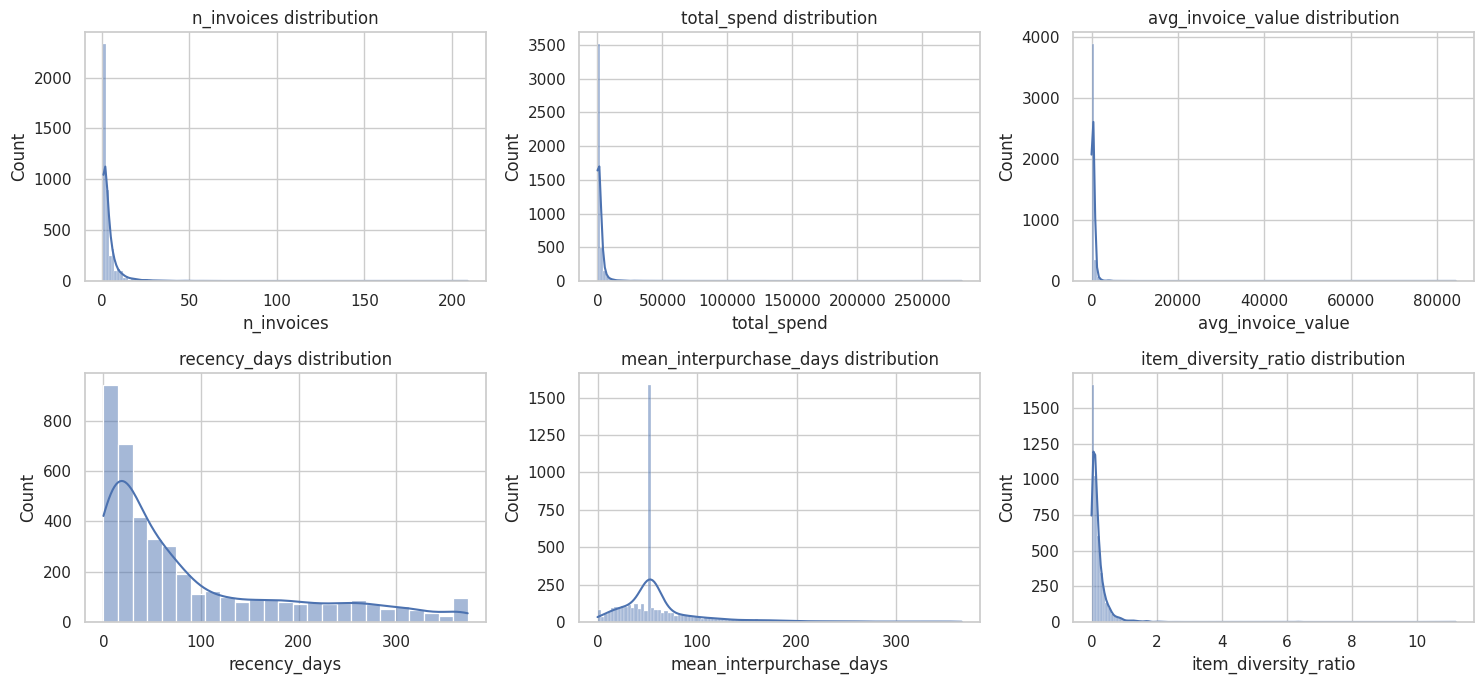

In [7]:
# Marginal distributions for requested engineered features
requested_features = [
    "n_invoices",
    "total_spent",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]

plot_df = customer_features_base.copy()

# Handle naming difference: total_spent (requested) vs total_spend (current feature name)
feature_lookup = {"total_spent": "total_spend"}
plot_features = [feature_lookup.get(f, f) for f in requested_features if feature_lookup.get(f, f) in plot_df.columns]

# Summary table for the selected features
summary_table = (
    plot_df[plot_features]
    .apply(pd.to_numeric, errors="coerce")
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
    .T
)
display(summary_table)

n_cols = 3
n_rows = int(np.ceil(len(plot_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(plot_features):
    vals = pd.to_numeric(plot_df[col], errors="coerce").dropna()
    sns.histplot(vals, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} distribution")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Customer activity is sparse for most users as shown by n_invoices median is 2, while the mean is 4.27 and max is 209, showing a long right tail (few very frequent buyers).
Spending is highly concentrated with total_spend median is 669, but p99 is 19,780 and max is 280,206 so a small minority drives a disproportionate share of revenue.
Average invoice value is also heavy-tailed with median 292 and max 84,236. This suggests occasional very large orders that inflate means.
Recency is broad and heterogeneous with median 50 days, p75 141, p99 368. The base contains both recently active and long-dormant customers.
Purchase cadence varies substantially mean_interpurchase_days median 53.5, p95 210.8, max 366. There are both frequent-repeat and slow-cycle customers.
Product variety is mostly low/moderate as item_diversity_ratio median 0.12, with a long tail up to 11.18, indicating most customers buy relatively concentrated sets of items, while a few are highly varied.

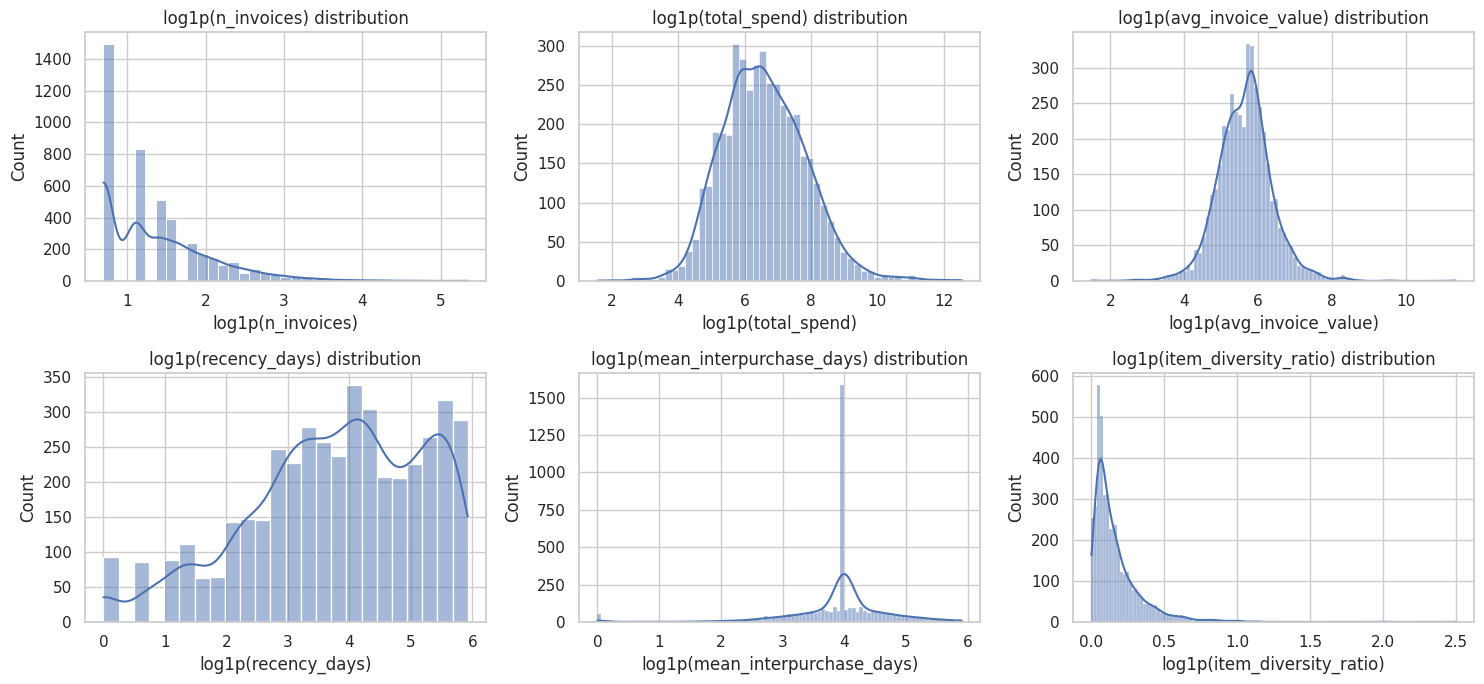

In [8]:
# Log-transformed marginal distributions (log1p)
log_features = [
    "n_invoices",
    "total_spend",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]

plot_df = customer_features_base.copy()

n_cols = 3
n_rows = int(np.ceil(len(log_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(log_features):
    vals = pd.to_numeric(plot_df[col], errors="coerce").dropna()
    vals = vals[vals >= 0]  # log1p requires non-negative values
    sns.histplot(np.log1p(vals), kde=True, ax=axes[i])
    axes[i].set_title(f"log1p({col}) distribution")
    axes[i].set_xlabel(f"log1p({col})")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Applying log1p transformation compresses the extreme right tails in the customer-level features while preserving rank order and relative differences among customers. After transformation, total_spend, avg_invoice_value, and mean_interpurchase_days become much more symmetric and concentrated around their central ranges, making underlying structure easier to visualize. n_invoices remains discrete and right-skewed, but the dominance of high-frequency outliers is reduced. item_diversity_ratio is still right-skewed, though its tail is materially compressed. recency_days appears broader and mildly multimodal, suggesting multiple behavioral groups (recently active vs dormant customers) rather than a single homogeneous population.

,StockCode,freq,cum_share
0,85123A,2023,0.52%
1,22423,1713,0.95%
2,85099B,1615,1.36%
3,84879,1395,1.72%
4,47566,1389,2.07%
5,20725,1304,2.40%
6,22720,1152,2.70%
7,POST,1099,2.98%
8,23203,1091,3.25%
9,20727,1078,3.53%


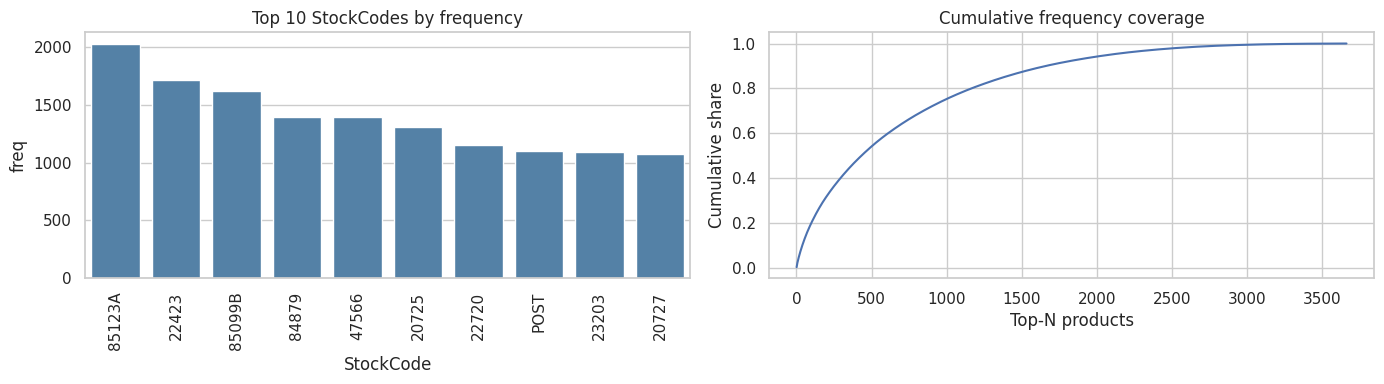

Top  10 items cover 3.53% of line items
Top  20 items cover 6.11% of line items
Top  50 items cover 12.36% of line items
Top 100 items cover 20.33% of line items
Top 500 items cover 54.21% of line items


In [9]:
# Product Performance and Basket Composition
product_counts = (
    customer_events.groupby("StockCode", as_index=False)
    .agg(freq=("InvoiceNo", "count"))
    .sort_values("freq", ascending=False)
    .reset_index(drop=True)
)

product_counts["cum_share"] = product_counts["freq"].cumsum() / product_counts["freq"].sum()

# Top-10 table
top10_stocks = product_counts.head(10).copy()
top10_stocks["cum_share"] = top10_stocks["cum_share"].map(lambda x: f"{x:.2%}")
display(top10_stocks)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=product_counts.head(10), x="StockCode", y="freq", ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 StockCodes by frequency")
axes[0].tick_params(axis="x", rotation=90)

axes[1].plot(np.arange(1, len(product_counts)+1), product_counts["cum_share"].values)
axes[1].set_title("Cumulative frequency coverage")
axes[1].set_xlabel("Top-N products")
axes[1].set_ylabel("Cumulative share")

plt.tight_layout()
plt.show()

for n in [10, 20, 50, 100, 500]:
    if n <= len(product_counts):
        share = product_counts.loc[n-1, "cum_share"]
        print(f"Top {n:>3} items cover {share:.2%} of line items")


### Interpretation

- Country contribution is uneven, with a few markets driving most transactions and spend.
- Differences between customer share and spend share reveal markets with higher/lower spend intensity per customer.
- Country-level effects should be preserved as features or grouping controls in evaluation.


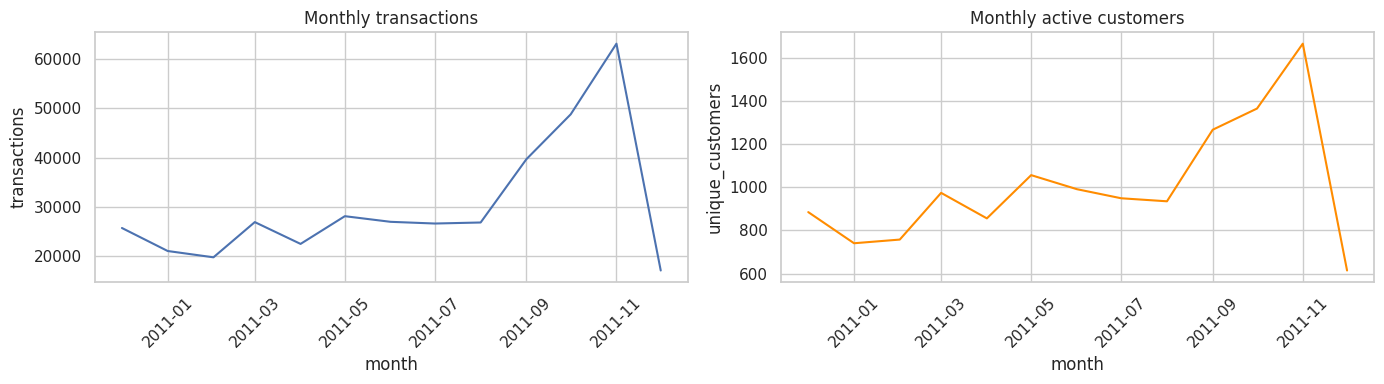

,month,transactions,unique_customers,total_spend
8,2011-08-01,26790,935,644051.040
9,2011-09-01,39669,1266,950690.202
10,2011-10-01,48793,1364,1035642.450
11,2011-11-01,63168,1664,1156205.610
12,2011-12-01,17026,615,517190.440


In [10]:
# Temporal Trends (Hourly, Weekly, Monthly Seasonality)
"""Question: How do transactions and active customers evolve over calendar time?"""
monthly = (
    customer_events.assign(month=customer_events["InvoiceDate"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(
        transactions=("InvoiceNo", "count"),
        unique_customers=("CustomerID", "nunique"),
        total_spend=("LineAmount", "sum"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=monthly, x="month", y="transactions", ax=axes[0])
axes[0].set_title("Monthly transactions")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=monthly, x="month", y="unique_customers", ax=axes[1], color="darkorange")
axes[1].set_title("Monthly active customers")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

display(monthly.tail())

### Interpretation

- Activity changes over months in both transaction volume and active-customer count.
- Periods where volume and customer count diverge indicate shifts in basket size/intensity, not just audience size.
- Time-aware validation and temporal features are justified for downstream modeling.

From August through November 2011, both transactions and unique customers rise together (26,790 → 63,168 lines; 935 → 1,664 customers), and total spend rises in step (~644k → ~1.16M). That pattern fits a strong seasonal ramp (often holiday-driven): more people buying and more activity per month.

December looks inconsistent with that trend: transactions and customers collapse (17,026; 615) while spend is still substantial (~517k). That usually means December is incomplete in the extract (only part of the month is recorded), not that demand truly crashed overnight.


### Returns/Cancellations Impact Analysis

- Quantify cancellation share of transactions and revenue impact.
- Identify products/customers with highest return exposure.
- Compare return behavior over time and by country.


In [11]:
# Returns/Cancellations Impact Analysis
"""Question: How large is cancellation exposure, and where is it concentrated?"""

returns_view = transactions_clean.copy()
returns_view["is_return_line"] = returns_view["Quantity"] < 0

returns_kpi = pd.DataFrame({
    "metric": [
        "cancel_invoice_rate",
        "return_line_rate",
        "gross_sales",
        "net_sales",
        "negative_line_amount",
    ],
    "value": [
        returns_view["is_cancel_invoice"].mean(),
        returns_view["is_return_line"].mean(),
        round(returns_view.loc[returns_view["LineAmount"] > 0, "LineAmount"].sum(), 2),
        round(returns_view["LineAmount"].sum(), 2),
        round(returns_view.loc[returns_view["LineAmount"] < 0, "LineAmount"].sum(), 2),
    ],
})
display(returns_kpi)

returns_by_country = (
    returns_view.groupby("Country", as_index=False)
    .agg(
        lines=("InvoiceNo", "count"),
        cancel_rate=("is_cancel_invoice", "mean"),
        return_rate=("is_return_line", "mean"),
        net_sales=("LineAmount", "sum"),
    )
    .sort_values("net_sales", ascending=False)
)
display(returns_by_country.head(15))


,metric,value
0,cancel_invoice_rate,2.209141e-02
1,return_line_rate,2.209141e-02
2,gross_sales,8.887209e+06
3,net_sales,8.278519e+06
4,negative_line_amount,-6.086895e+05


,Country,lines,cancel_rate,return_rate,net_sales
35,United Kingdom,356728,0.021027,0.021027,6747156.154
23,Netherlands,2371,0.003374,0.003374,284661.540
10,EIRE,7475,0.033043,0.033043,250001.780
14,Germany,9480,0.047785,0.047785,221509.470
13,France,8475,0.017463,0.017463,196626.050
0,Australia,1258,0.058824,0.058824,137009.770
32,Switzerland,1877,0.018647,0.018647,55739.400
30,Spain,2528,0.018987,0.018987,54756.030
3,Belgium,2069,0.018366,0.018366,40910.960
31,Sweden,461,0.023861,0.023861,36585.410


### Interpretation

- Cancel and return **line rates** are both ~**2.2%**.  
- **Gross sales** (~**£8.89M**) uses positive lines only; **net sales** (~**£8.28M**) includes returns — about **£609k** (~**6.9%** of gross) is clawed back.  
- **UK** dominates volume/revenue with rates near ~**2%**; a few markets show **much higher rates** (e.g. **Japan ~10%**, **Australia ~6%**, **Germany ~5%**) — flag for quality checks.  

# PCA

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

raw_cols = [
    "n_invoices",
    "total_spend",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]

# ----------  Sequence-stat representation ----------
seq_extra = invoice_level.groupby("CustomerID", as_index=False).agg(
    invoice_value_std=("invoice_value", "std"),
    invoice_value_median=("invoice_value", "median"),
    interpurchase_days_std=("interpurchase_days", "std"),
    interpurchase_days_median=("interpurchase_days", "median"),
)

seq_extra["invoice_value_std"] = seq_extra["invoice_value_std"].fillna(0)
seq_extra["interpurchase_days_std"] = seq_extra["interpurchase_days_std"].fillna(0)

# Coefficient of variation proxies (guard against divide-by-zero)
seq_extra = seq_extra.merge(
    invoice_level.groupby("CustomerID", as_index=False).agg(invoice_value_mean=("invoice_value", "mean")),
    on="CustomerID",
    how="left",
)
seq_extra["invoice_value_cv"] = np.where(
    seq_extra["invoice_value_mean"].abs() > 1e-9,
    seq_extra["invoice_value_std"] / seq_extra["invoice_value_mean"].abs(),
    0.0,
)
seq_extra = seq_extra.drop(columns=["invoice_value_mean"])

X_seq = customer_features_base[["CustomerID"] + raw_cols].merge(seq_extra, on="CustomerID", how="left")
seq_cols = [c for c in X_seq.columns if c != "CustomerID"]
X_seq[seq_cols] = X_seq[seq_cols].apply(pd.to_numeric, errors="coerce")
X_seq[seq_cols] = X_seq[seq_cols].fillna(X_seq[seq_cols].median(numeric_only=True))

# ----------  Latent representation (PCA + cluster metadata) ----------
latent_input_cols = [c for c in X_seq.columns if c != "CustomerID"]
latent_input = X_seq[latent_input_cols].copy()

scaler = StandardScaler()
latent_scaled = scaler.fit_transform(latent_input)

# Keep enough components to explain 90% variance.
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
latent_array = pca.fit_transform(latent_scaled)
pca_cols = [f"pca_{i+1}" for i in range(latent_array.shape[1])]

X_latent = pd.DataFrame(latent_array, columns=pca_cols, index=X_seq.index)
X_latent.insert(0, "CustomerID", X_seq["CustomerID"].values)

# Add lightweight unsupervised segment metadata for later comparison.
kmeans = KMeans(n_clusters=5, n_init=10, random_state=RANDOM_STATE)
cluster_id = kmeans.fit_predict(latent_array)
cluster_dist = kmeans.transform(latent_array).min(axis=1)

X_latent["cluster_id"] = cluster_id
X_latent["cluster_dist"] = cluster_dist

# ---------- Representation registry ----------
representations = {
    "raw": customer_features_base[["CustomerID"] + raw_cols].copy(),
    "sequence": X_seq,
    "latent": X_latent,
}

pca_explained = float(pca.explained_variance_ratio_.sum())
print(f"PCA components: {len(pca_cols)} | explained variance: {pca_explained:.3f}")
print("Representations prepared:", list(representations.keys()))

X_latent.head()

PCA components: 7 | explained variance: 0.949
Representations prepared: ['raw', 'sequence', 'latent']


,CustomerID,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,cluster_id,cluster_dist
0,12346,45.095390,-23.079606,-9.215899,2.560134,11.424267,-0.315932,-5.088377,3,21.121829
1,12347,0.568918,0.523082,0.438082,0.246093,-0.382033,-0.605412,0.375981,2,0.972995
2,12348,0.243501,0.142698,1.172137,1.330833,-0.557239,0.681658,-0.214725,2,1.669026
3,12349,0.417187,-0.827065,-0.731554,0.061367,0.259337,-1.295056,-0.330464,0,1.641685
4,12350,-0.763267,-1.033142,-1.675965,-0.647250,-0.012234,1.261781,-0.252143,0,1.632062


### Interpretation

The latent representation was constructed to compress customer behavior into a compact, information-preserving feature space before classification. Starting from the enriched sequence feature matrix, all variables were standardized and projected using PCA with n_components=0.90, which automatically selected 7 principal components and retained 94.9% of the total variance (explained variance = 0.949). This indicates that most of the original behavioral signal is preserved while removing redundancy and noise from correlated engineered features. To complement these continuous latent factors (pca_1–pca_7), KMeans segmentation metadata (cluster_id, cluster_dist) was added, where cluster_dist captures how typical each customer is within its segment. Together, this latent representation provides a lower-dimensional, denoised, and behaviorally structured input that is well-suited for downstream model comparison against the raw and sequence feature sets.

## 6) Unsupervised Analysis

Evaluate whether meaningful customer segments emerge across all representation families (`raw`, `sequence`, `latent`) using a consistent clustering protocol.

### Method
- Clustering algorithm: `KMeans`
- Cluster search grid: `k = 2..8`
- Shared metrics: silhouette, Calinski-Harabasz, Davies-Bouldin, inertia
- Selection rule: maximize silhouette; tie-break by lower Davies-Bouldin

In [13]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [14]:
# CustomerID alignment, numeric cleaning, and StandardScaler per representation
base_customers = set(customer_features_base["CustomerID"])
feature_matrices = {}
feature_columns = {}
scaled_matrices = {}
representation_scalers = {}
prep_rows = []

for name, df_repr in representations.items():
    assert set(df_repr["CustomerID"]) == base_customers, f"CustomerID mismatch in {name}"
    feats = [c for c in df_repr.columns if c != "CustomerID"]
    source_nulls = int(df_repr[feats].isna().sum().sum())

    X = df_repr[feats].apply(pd.to_numeric, errors="coerce")
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(X)

    feature_matrices[name] = X
    feature_columns[name] = feats
    scaled_matrices[name] = X_scaled
    representation_scalers[name] = scaler_local

    prep_rows.append({
        "representation": name,
        "n_rows": X.shape[0],
        "n_features": X.shape[1]
    })

prep_summary = pd.DataFrame(prep_rows)
prep_summary


,representation,n_rows,n_features
0,raw,4338,6
1,sequence,4338,11
2,latent,4338,9


In [15]:
# KMeans sweep across k for each representation
k_grid = list(range(2, 9))
cluster_metric_rows = []

for name, X_scaled in scaled_matrices.items():
    for k in k_grid:
        km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
        labels = km.fit_predict(X_scaled)

        cluster_metric_rows.append({
            "representation": name,
            "k": k,
            "silhouette": float(silhouette_score(X_scaled, labels)),
            "calinski_harabasz": float(calinski_harabasz_score(X_scaled, labels)),
            "davies_bouldin": float(davies_bouldin_score(X_scaled, labels)),
            "inertia": float(km.inertia_),
        })

cluster_metric_grid_df = pd.DataFrame(cluster_metric_rows).sort_values(["representation", "k"]).reset_index(drop=True)
cluster_metric_grid_df.head(15)


,representation,k,silhouette,calinski_harabasz,davies_bouldin,inertia
0,latent,2,0.316167,1005.210800,1.507252,31694.332678
1,latent,3,0.318400,921.323338,1.109533,27396.689853
2,latent,4,0.315440,913.259821,1.118857,23920.455658
3,latent,5,0.368585,990.418087,1.032056,20394.896738
4,latent,6,0.380028,1023.869762,1.025407,17894.805563
5,latent,7,0.373690,1103.347993,0.972218,15440.595562
6,latent,8,0.374506,1190.292410,0.894339,13351.068883
7,raw,2,0.904789,986.881127,1.130742,21202.316057
8,raw,3,0.344805,1081.639636,1.067914,17363.270378
9,raw,4,0.346160,1296.377284,0.830421,13718.054045


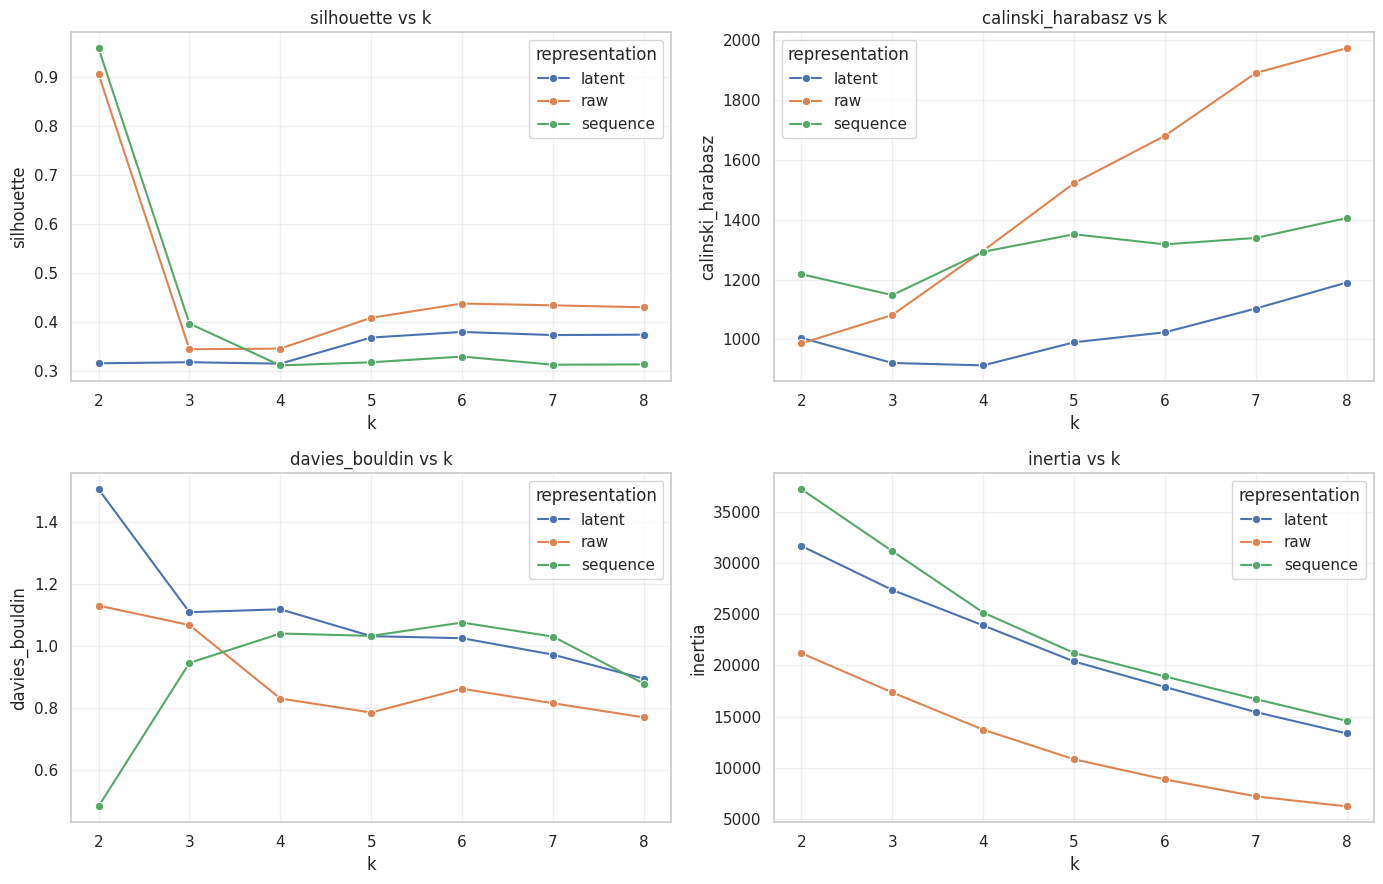

In [16]:
# Metric-vs-k plots across representations
metrics_to_plot = ["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, metric in zip(axes, metrics_to_plot):
    sns.lineplot(data=cluster_metric_grid_df, x="k", y=metric, hue="representation", marker="o", ax=ax)
    ax.set_title(f"{metric} vs k")
    ax.set_xlabel("k")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

I evaluated KMeans on three customer representations—raw, sequence (raw plus invoice-level summary statistics), and latent (PCA-compressed features with light cluster metadata)—over k = 2…8, using silhouette, Calinski–Harabasz, Davies–Bouldin, and inertia for comparison. Silhouette was used as the primary selection criterion, with lower Davies–Bouldin as a tie-break when silhouettes were similar.

sequence and raw both exhibited very strong two-cluster structure, with silhouette near 0.96 (sequence, k = 2) and ~0.90 (raw, k = 2). For these representations, silhouette dropped sharply at small k > 2 before partially recovering at larger k (notably raw showed a secondary peak around k ≈ 6), indicating that the dominant geometry is a strong binary split rather than a smooth progression of equally well-separated multi-cluster solutions. sequence improved on raw at k = 2 under complementary separation signals as well (e.g., lower Davies–Bouldin in the reported table), consistent with added sequence variability features sharpening segment boundaries.

latent produced materially lower silhouette scores overall (roughly 0.32–0.38 in the reported grid), reflecting dimensionality reduction and mixing of signal. In latent space, clustering metrics improved more gradually with k, with the best silhouette occurring around moderate k (about k = 6 in the table) while Calinski–Harabasz rose and Davies–Bouldin generally improved as k increased—suggesting finer-grained but less “globally crisp” partitions than the near-binary splits seen in raw/sequence.


In [17]:
# Select best k per representation (silhouette max, Davies-Bouldin min tie-break)
best_models = {}
selected_labels = {}
best_rows = []

for name in cluster_metric_grid_df["representation"].unique():
    subset = cluster_metric_grid_df[cluster_metric_grid_df["representation"] == name].copy()
    subset = subset.sort_values(["silhouette", "davies_bouldin"], ascending=[False, True])
    best = subset.iloc[0]
    best_k = int(best["k"])

    km_best = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE)
    labels_best = km_best.fit_predict(scaled_matrices[name])

    best_models[name] = km_best
    selected_labels[name] = labels_best

    best_rows.append({
        "representation": name,
        "selected_k": best_k,
        "silhouette": float(best["silhouette"]),
        "calinski_harabasz": float(best["calinski_harabasz"]),
        "davies_bouldin": float(best["davies_bouldin"]),
        "inertia": float(best["inertia"]),
    })

best_cluster_summary_df = pd.DataFrame(best_rows)
best_cluster_summary_df["rank_silhouette"] = best_cluster_summary_df["silhouette"].rank(ascending=False, method="dense").astype(int)
best_cluster_summary_df = best_cluster_summary_df.sort_values("rank_silhouette")
display(best_cluster_summary_df)

,representation,selected_k,silhouette,calinski_harabasz,davies_bouldin,inertia,rank_silhouette
2,sequence,2,0.957764,1218.111854,0.481559,37252.625339,1
1,raw,2,0.904789,986.881127,1.130742,21202.316057,2
0,latent,6,0.380028,1023.869762,1.025407,17894.805563,3


In [18]:
from IPython.display import display
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

# Same scaled latent matrix and labels used for the KMeans sweep / selection.
X_latent = scaled_matrices["latent"]
labels_km = selected_labels["latent"]
k_latent = int(
    best_cluster_summary_df.loc[
        best_cluster_summary_df["representation"] == "latent", "selected_k"
    ].iloc[0]
)

agg_model = AgglomerativeClustering(n_clusters=k_latent, linkage="ward")
labels_agg = agg_model.fit_predict(X_latent)

ari = adjusted_rand_score(labels_km, labels_agg)
nmi = normalized_mutual_info_score(labels_km, labels_agg)
sil_km = silhouette_score(X_latent, labels_km)
sil_agg = silhouette_score(X_latent, labels_agg)

print(f"Latent k (matches KMeans selection): {k_latent}")
print(f"Adjusted Rand Index (KMeans vs Agglomerative): {ari:.6f}")
print(f"Normalized Mutual Information (KMeans vs Agglomerative): {nmi:.6f}")
print(f"Silhouette with KMeans labels on X_latent: {sil_km:.6f}")
print(f"Silhouette with Agglomerative labels on X_latent: {sil_agg:.6f}")

km_counts = pd.Series(labels_km).value_counts().reindex(range(k_latent), fill_value=0).astype(int)
agg_counts = pd.Series(labels_agg).value_counts().reindex(range(k_latent), fill_value=0).astype(int)

compare_sizes = pd.DataFrame(
    {
        "cluster_id": list(range(k_latent)),
        "kmeans_n": km_counts.values,
        "agglomerative_n": agg_counts.values,
    }
)
display(compare_sizes)

agg_vs_kmeans = {
    "k_latent": k_latent,
    "ari": ari,
    "nmi": nmi,
    "silhouette_kmeans": sil_km,
    "silhouette_agglomerative": sil_agg,
}

Latent k (matches KMeans selection): 6
Adjusted Rand Index (KMeans vs Agglomerative): 0.943154
Normalized Mutual Information (KMeans vs Agglomerative): 0.884745
Silhouette with KMeans labels on X_latent: 0.380028
Silhouette with Agglomerative labels on X_latent: 0.368773


,cluster_id,kmeans_n,agglomerative_n
0,0,364,2017
1,1,2014,8
2,2,1570,399
3,3,361,1549
4,4,2,363
5,5,27,2


### Agglomerative clustering vs KMeans (latent, fixed k)

**Comparison.** On the same standardized latent feature matrix, **Ward** agglomerative clustering with **k = 6** produces partitions that **agree closely** with KMeans. **ARI**, **NMI**, and both **silhouette** scores are printed in the **preceding code cell**—high ARI/NMI means alignment up to **permutation of cluster labels**, not a conflicting taxonomy; similar silhouettes on `X_latent` for the two labelings support that reading. The side-by-side **cluster size** table shows how mass is allocated under each method at fixed *k*.

KMeans is **fast** at customer scale, supports the published **k = 2…8 metric sweep** (silhouette, Calinski–Harabasz, Davies–Bouldin, inertia), and yields **interpretable centroids** in the same Euclidean geometry used for those scores. 

**Limitations of KMeans:** 
- it prefers **roughly spherical / variance-balanced** groups
- it remains **sensitive to outliers** (partly mitigated by scaling)
- **k is externally chosen**
- random initialization variance is reduced via **high `n_init`**. 

**Agglomerative** clustering here is a **methodological cross-check**: strong agreement indicates the latent six-cluster structure is **robust** to swapping centroid-based partitioning for hierarchical merges at the same *k*, rather than being an artifact unique to KMeans.

Under silhouette-first selection, sequence features at k = 2 yield the most separated customer partitions, raw remains strongly binary at k = 2 but less crisp than sequence, and the latent embedding favors more segments (k = 6) with substantially weaker global cluster separation by silhouette.

In [19]:
# Segment profiles on business-facing features
profile_base_cols = [
    "CustomerID",
    "n_invoices",
    "total_spend",
    "avg_invoice_value",
    "recency_days",
    "mean_interpurchase_days",
    "item_diversity_ratio",
]

profile_base = customer_features_base[profile_base_cols].copy()
segment_profiles = {}
segment_sizes = {}

for name, labels in selected_labels.items():
    col = f"cluster_{name}"
    prof = profile_base.copy()
    prof[col] = labels

    size_tbl = (
        prof.groupby(col, as_index=False)
        .agg(customers=("CustomerID", "count"))
        .sort_values("customers", ascending=False)
    )
    size_tbl["share"] = size_tbl["customers"] / size_tbl["customers"].sum()

    numeric_profile_cols = [
        "n_invoices",
        "total_spend",
        "avg_invoice_value",
        "recency_days",
        "mean_interpurchase_days",
        "item_diversity_ratio",
    ]
    prof[numeric_profile_cols] = prof[numeric_profile_cols].apply(pd.to_numeric, errors="coerce")

    profile_tbl = prof.groupby(col, as_index=False).agg({
        "n_invoices": ["mean", "median"],
        "total_spend": ["mean", "median"],
        "avg_invoice_value": ["mean", "median"],
        "recency_days": ["mean", "median"],
        "mean_interpurchase_days": ["mean", "median"],
        "item_diversity_ratio": ["mean", "median"],
    })
    profile_tbl.columns = [
        col if isinstance(col, str) else f"{col[0]}_{col[1]}" 
        for col in profile_tbl.columns
    ]

    segment_sizes[name] = size_tbl
    segment_profiles[name] = profile_tbl

for name in segment_sizes:
    print(f"\n=== Segment sizes: {name} ===")
    display(segment_sizes[name])
    print(f"=== Segment profile: {name} ===")
    display(segment_profiles[name].head())



=== Segment sizes: latent ===


,cluster_latent,customers,share
1,1,2014,0.464269
2,2,1570,0.361918
0,0,364,0.08391
3,3,361,0.083218
5,5,27,0.006224
4,4,2,0.000461


=== Segment profile: latent ===


,cluster_latent_,n_invoices_mean,n_invoices_median,total_spend_mean,total_spend_median,avg_invoice_value_mean,avg_invoice_value_median,recency_days_mean,recency_days_median,mean_interpurchase_days_mean,mean_interpurchase_days_median,item_diversity_ratio_mean,item_diversity_ratio_median
0,0,2.098901,2.0,702.521703,574.735,335.788745,269.32750,60.862637,49.0,207.859432,190.000000,0.157656,0.112331
1,1,1.413108,1.0,508.247558,317.455,356.396423,271.35000,147.226912,122.5,54.518701,53.500000,0.092894,0.064691
2,2,7.450955,6.0,3021.058008,1861.390,395.100261,314.02975,39.482166,21.0,41.394063,38.333333,0.327910,0.234098
3,3,3.883657,4.0,1513.446371,1079.610,405.920905,276.76600,44.185596,25.0,98.824024,93.333333,0.270296,0.180794
4,4,1.500000,1.5,122828.050000,122828.050,80709.925000,80709.92500,162.500000,162.5,129.250000,129.250000,0.000024,0.000024



=== Segment sizes: raw ===


...

,cluster_raw_,n_invoices_mean,n_invoices_median,total_spend_mean,total_spend_median,avg_invoice_value_mean,avg_invoice_value_median,recency_days_mean,recency_days_median,mean_interpurchase_days_mean,mean_interpurchase_days_median,item_diversity_ratio_mean,item_diversity_ratio_median
0,0,73.882353,60.0,106414.075294,80850.84,11179.289432,1300.792400,25.352941,2.0,20.776521,6.220339,1.965222,0.281367
1,1,3.998149,2.0,1638.086002,664.11,375.306475,290.708889,91.796806,50.0,66.239928,53.500000,0.199432,0.119743



=== Segment sizes: sequence ===


,cluster_sequence,customers,share
0,0,4336,0.999539
1,1,2,0.000461


=== Segment profile: sequence ===


,cluster_sequence_,n_invoices_mean,n_invoices_median,total_spend_mean,total_spend_median,avg_invoice_value_mean,avg_invoice_value_median,recency_days_mean,recency_days_median,mean_interpurchase_days_mean,mean_interpurchase_days_median,item_diversity_ratio_mean,item_diversity_ratio_median
0,0,4.273293,2.0,1992.978043,668.495,380.610551,291.8775,91.50369,50.0,66.032618,53.50,0.206447,0.120303
1,1,1.500000,1.5,122828.050000,122828.050,80709.925000,80709.9250,162.50000,162.5,129.250000,129.25,0.000024,0.000024


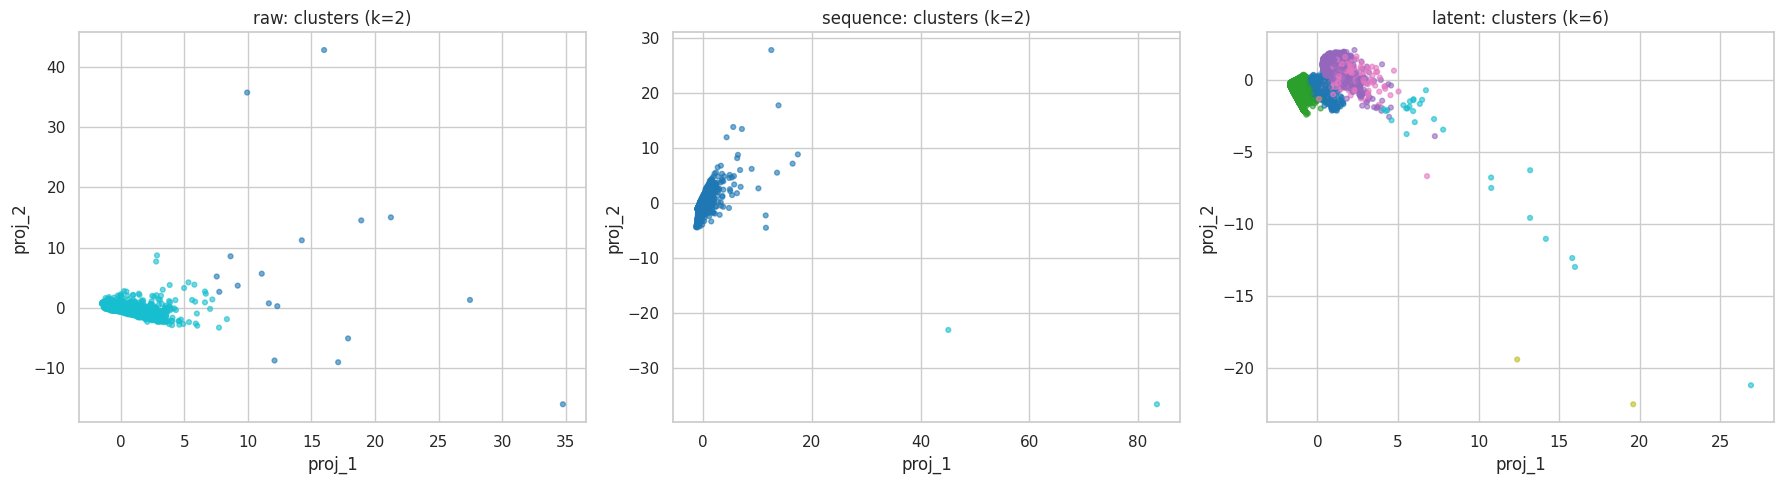

In [20]:
# 2D diagnostic scatter using PCA projection of each representation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, name in zip(axes, ["raw", "sequence", "latent"]):
    X_scaled = scaled_matrices[name]
    labels = selected_labels[name]

    proj = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
    ax.scatter(proj[:, 0], proj[:, 1], c=labels, s=12, alpha=0.6, cmap="tab10")
    ax.set_title(f"{name}: clusters (k={best_cluster_summary_df.set_index('representation').loc[name, 'selected_k']})")
    ax.set_xlabel("proj_1")
    ax.set_ylabel("proj_2")

plt.tight_layout()
plt.show()

Although raw/sequence achieved high silhouette at k=2, their segment sizes show heavily imbalanced splits dominated by one large cluster and a tiny outlier cluster, indicating outlier separation rather than rich customer taxonomy. In contrast, the latent representation at k=6 produced a more granular and interpretable segmentation with multiple non-trivial groups and distinct behavioral profiles (purchase frequency, spend level, recency, interpurchase timing, and diversity). Therefore, latent clustering is more suitable for downstream analysis and action-oriented segmentation, while raw/sequence k=2 solutions are better interpreted as anomaly-vs-main-population partitions.

### t-SNE Projection

This adds a nonlinear projection view to complement KMeans/PCA diagnostics, helping visualize local cluster overlap/separation structure.


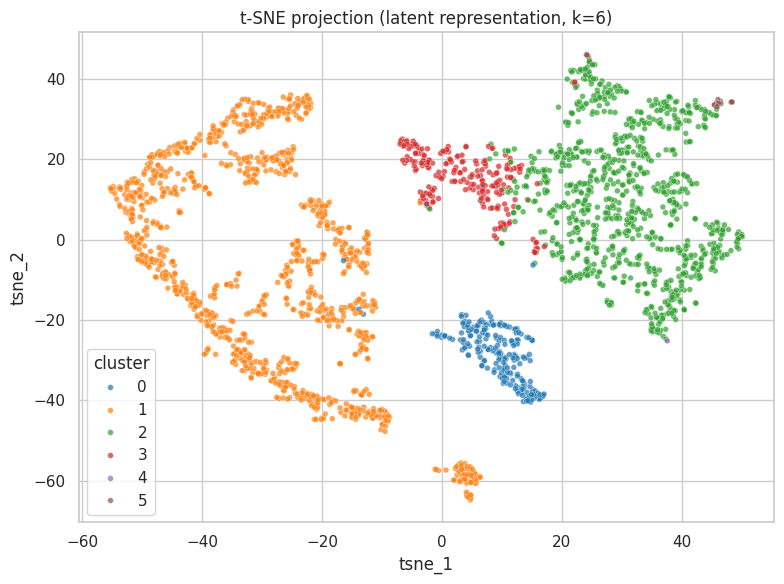

,cluster,n_customers,share
0,0,211,0.0844
1,1,1141,0.4564
2,2,913,0.3652
3,3,218,0.0872
4,4,1,0.0004
5,5,16,0.0064


In [21]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

repr_for_tsne = "latent"
k_for_tsne = 6
X_best = scaled_matrices[repr_for_tsne]

latent_labels_obj = selected_labels[repr_for_tsne]
if isinstance(latent_labels_obj, dict):
    labels_best = latent_labels_obj[k_for_tsne]
else:
    labels_best = latent_labels_obj

sample_n = min(2500, X_best.shape[0])
idx = np.random.RandomState(RANDOM_STATE).choice(X_best.shape[0], sample_n, replace=False)
X_sample = X_best[idx]
labels_sample = np.array(labels_best)[idx]

tsne = TSNE(n_components=2, random_state=RANDOM_STATE, init='pca', learning_rate='auto', perplexity=30)
proj_tsne = tsne.fit_transform(X_sample)

tsne_df = pd.DataFrame({'tsne_1': proj_tsne[:,0], 'tsne_2': proj_tsne[:,1], 'cluster': labels_sample})

plt.figure(figsize=(8,6))
sns.scatterplot(data=tsne_df, x='tsne_1', y='tsne_2', hue='cluster', palette='tab10', s=18, alpha=0.7)
plt.title(f't-SNE projection ({repr_for_tsne} representation, k={k_for_tsne})')
plt.tight_layout()
plt.show()

tsne_cluster_table = (
    tsne_df["cluster"]
    .value_counts()
    .rename_axis("cluster")
    .reset_index(name="n_customers")
    .sort_values("cluster")
)
tsne_cluster_table["share"] = tsne_cluster_table["n_customers"] / tsne_cluster_table["n_customers"].sum()
display(tsne_cluster_table.reset_index(drop=True))



 t-SNE yields four meaningful customer groups covering ~99.3% of the sample and two very small tail segments (including a singleton outlier), indicating that the model captures both broad behavioral regimes and rare extreme profiles. For managerial interpretation, focus on the four large clusters(clusters 1,2,3,0) and treat the smallest clusters(clusters 4,5) as anomaly/high-value edge cases requiring separate handling.

## 7) Supervised Modeling (NN + Transformer)

Goal: predict customer behavioral segments from purchase-event sequences and compare a neural baseline against a Transformer under the same split/metric protocol.


In [22]:
# Supervised modeling setup: reproducibility, device, and shared utilities
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

try:
    import torch
except ModuleNotFoundError:
    %pip install torch
    import torch

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

modeling_random_state = int(RANDOM_STATE) if 'RANDOM_STATE' in globals() else 42
random.seed(modeling_random_state)
np.random.seed(modeling_random_state)
torch.manual_seed(modeling_random_state)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(modeling_random_state)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Modeling device:', device)


Modeling device: cuda


Supervised task: **customer segmentation prediction**.

- Target labels come from clustering (`selected_labels['sequence']`.
- Inputs are customer event sequences ordered by `InvoiceDate`.
- This links unsupervised structure discovery  with downstream predictive modeling and direct model comparison.


In [23]:
# Build customer-level targets
if "selected_labels" not in globals():
    raise ValueError("selected_labels not found. Run clustering cells first.")

target_source = "latent"
target_k = 6

latent_labels_obj = selected_labels[target_source]
if isinstance(latent_labels_obj, dict):
    target_labels = latent_labels_obj[target_k]
else:
    # Fallback if labels are already a single selected vector
    target_labels = latent_labels_obj

customer_target_df = pd.DataFrame({
    "CustomerID": customer_features_base["CustomerID"].values,
    "segment_label": target_labels,
})

label_encoder = LabelEncoder()
customer_target_df["y"] = label_encoder.fit_transform(customer_target_df["segment_label"])

print("Target source:", target_source)
print("Target k:", target_k)
print("Class distribution:")
display(
    customer_target_df["y"]
    .value_counts(normalize=True)
    .sort_index()
    .rename("share")
    .to_frame()
)


Target source: latent
Target k: 6
Class distribution:


,share
y,
0,0.083910
1,0.464269
2,0.361918
3,0.083218
4,0.000461
5,0.006224


The supervised target was generated from the latent clustering solution with k=6, producing six segment labels with a strongly imbalanced distribution. Two dominant classes account for ~82.6% of customers (y=1: 46.4%, y=2: 36.2%), two medium classes contribute ~16.7% (y=0, y=3), and two tail classes are rare (y=5: 0.62%, y=4: 0.046%). This indicates that the latent segmentation captures both broad customer regimes and small outlier-like groups, but it also introduces a challenging class-imbalance setting for downstream supervised modeling; therefore, evaluation should prioritize macro-averaged and class-wise metrics rather than accuracy alone.

In [24]:
# Sequence dataset construction from customer_events
required_cols = ['CustomerID', 'InvoiceDate', 'StockCode', 'Quantity', 'UnitPrice', 'LineAmount']
missing_cols = [c for c in required_cols if c not in customer_events.columns]
if missing_cols:
    raise ValueError(f'Missing required columns in customer_events: {missing_cols}')

ev = customer_events[required_cols].copy()
ev = ev[ev['CustomerID'].isin(customer_target_df['CustomerID'])].copy()
ev = ev.sort_values(['CustomerID', 'InvoiceDate', 'StockCode']).reset_index(drop=True)

# Customer-disjoint split with robust stratification fallback
all_ids = customer_target_df['CustomerID']
all_y = customer_target_df['y']

if all_y.value_counts().min() >= 2:
    train_ids, temp_ids = train_test_split(
        all_ids,
        test_size=0.30,
        random_state=modeling_random_state,
        stratify=all_y
    )
    first_split_stratified = True
else:
    train_ids, temp_ids = train_test_split(
        all_ids,
        test_size=0.30,
        random_state=modeling_random_state,
        stratify=None
    )
    first_split_stratified = False

temp_targets = customer_target_df.set_index('CustomerID').loc[temp_ids, 'y']
if temp_targets.nunique() > 1 and temp_targets.value_counts().min() >= 2:
    val_ids, test_ids = train_test_split(
        temp_ids,
        test_size=0.50,
        random_state=modeling_random_state,
        stratify=temp_targets
    )
    second_split_stratified = True
else:
    val_ids, test_ids = train_test_split(
        temp_ids,
        test_size=0.50,
        random_state=modeling_random_state,
        stratify=None
    )
    second_split_stratified = False

train_ids = set(train_ids)
val_ids = set(val_ids)
test_ids = set(test_ids)

# Build token vocab from train split only (avoid split leakage)
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
train_stockcodes = ev[ev['CustomerID'].isin(train_ids)]['StockCode'].astype(str)
unique_codes = sorted(train_stockcodes.unique().tolist())

stockcode_to_idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for idx, code in enumerate(unique_codes, start=2):
    stockcode_to_idx[code] = idx

# Numeric context scaling (fit on train events only)
num_cols = ['Quantity', 'UnitPrice', 'LineAmount']
train_num = ev[ev['CustomerID'].isin(train_ids)][num_cols].astype(float)
num_mean = train_num.mean()
num_std = train_num.std().replace(0, 1.0)

# Group events into per-customer sequences
grouped = ev.groupby('CustomerID', sort=False)
sequence_records = []
for cust_id, frame in grouped:
    token_ids = [stockcode_to_idx.get(str(s), stockcode_to_idx[UNK_TOKEN]) for s in frame['StockCode'].astype(str)]
    nums = ((frame[num_cols].astype(float) - num_mean) / num_std).values.astype(np.float32)
    sequence_records.append({
        'CustomerID': cust_id,
        'token_ids': token_ids,
        'num_feats': nums,
        'seq_len': len(token_ids)
    })

seq_df = pd.DataFrame(sequence_records)
seq_df = seq_df.merge(customer_target_df[['CustomerID', 'y']], on='CustomerID', how='inner')

max_len = int(np.ceil(seq_df['seq_len'].quantile(0.95)))
max_len = max(20, min(max_len, 120))

print(f'Total customers in sequence table: {len(seq_df):,}')
print(f'Vocabulary size: {len(stockcode_to_idx):,}')
print(f'Max sequence length (p95-capped): {max_len}')
print('Split stratification:', {
    'first_split_stratified': first_split_stratified,
    'second_split_stratified': second_split_stratified,
})
print('Split sizes:', {
    'train': int(seq_df['CustomerID'].isin(train_ids).sum()),
    'val': int(seq_df['CustomerID'].isin(val_ids).sum()),
    'test': int(seq_df['CustomerID'].isin(test_ids).sum())
})


Total customers in sequence table: 4,338
Vocabulary size: 3,600
Max sequence length (p95-capped): 120
Split stratification: {'first_split_stratified': True, 'second_split_stratified': False}
Split sizes: {'train': 3036, 'val': 651, 'test': 651}


I constructed a customer-level sequential dataset containing 4,338 customers. Product-token vocabulary (built from the training split only to avoid leakage) contains 3,600 unique tokens including special symbols (PAD, UNK). Sequence length was set using a robust truncation rule at the 95th percentile, then capped, yielding max_len = 120. This preserves most behavioral history while controlling memory and training cost.

Customers were split disjointly into train/validation/test = 3036/651/651 (approximately 70/15/15), ensuring all events from a customer appear in exactly one partition. This prevents customer-level leakage in sequence modeling. The first split (train vs temp) was successfully stratified by target class, while the second split (validation vs test) fell back to non-stratified due to rare-class constraints (second_split_stratified = False), which is expected under highly imbalanced labels.

Overall, the preprocessing pipeline yields a leakage-aware and computationally tractable sequence dataset, with adequate scale for training deep sequence models and an explicit handling strategy for class imbalance and long-tail sequence lengths.

In [25]:
# Dataset + dataloader helpers
class CustomerSeqDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        tokens = row['token_ids'][:max_len]
        nums = row['num_feats'][:max_len]
        length = len(tokens)

        if length < max_len:
            pad_n = max_len - length
            tokens = tokens + [0] * pad_n
            nums = np.vstack([nums, np.zeros((pad_n, nums.shape[1]), dtype=np.float32)])

        mask = np.zeros(max_len, dtype=np.float32)
        mask[:min(length, max_len)] = 1.0

        return {
            'tokens': torch.tensor(tokens, dtype=torch.long),
            'num_feats': torch.tensor(nums, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'label': torch.tensor(int(row['y']), dtype=torch.long),
            'customer_id': torch.tensor(int(row['CustomerID']), dtype=torch.long)
        }

train_frame = seq_df[seq_df['CustomerID'].isin(train_ids)].copy()
val_frame = seq_df[seq_df['CustomerID'].isin(val_ids)].copy()
test_frame = seq_df[seq_df['CustomerID'].isin(test_ids)].copy()

train_ds = CustomerSeqDataset(train_frame)
val_ds = CustomerSeqDataset(val_frame)
test_ds = CustomerSeqDataset(test_frame)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

sample_batch = next(iter(train_loader))


In [26]:
# Shared train/eval utilities
NUM_CLASSES = int(customer_target_df['y'].nunique())
VOCAB_SIZE = len(stockcode_to_idx)
NUM_NUMERIC = 3


def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0.0
    all_preds, all_true = [], []

    for batch in loader:
        tokens = batch['tokens'].to(device)
        num_feats = batch['num_feats'].to(device)
        mask = batch['mask'].to(device)
        y = batch['label'].to(device)

        if train_mode:
            optimizer.zero_grad()

        logits = model(tokens, num_feats, mask)
        loss = loss_fn(logits, y)

        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * y.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_true.extend(y.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_true, all_preds)
    f1 = f1_score(all_true, all_preds, average='macro')
    return {'loss': avg_loss, 'acc': acc, 'f1': f1}


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for batch in loader:
            tokens = batch['tokens'].to(device)
            num_feats = batch['num_feats'].to(device)
            mask = batch['mask'].to(device)
            y = batch['label'].to(device)
            logits = model(tokens, num_feats, mask)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy().tolist())
            all_true.extend(y.detach().cpu().numpy().tolist())

    return {
        'acc': accuracy_score(all_true, all_preds),
        'f1_macro': f1_score(all_true, all_preds, average='macro'),
        'report': classification_report(all_true, all_preds, output_dict=True, zero_division=0),
        'confusion_matrix': confusion_matrix(all_true, all_preds),
        'y_true': np.array(all_true),
        'y_pred': np.array(all_preds)
    }


### Neural Baseline (GRU + pooled head)


In [27]:
class GRUBaseline(nn.Module):
    def __init__(self, vocab_size, num_numeric, num_classes, emb_dim=64, num_dim=16, hidden_dim=96):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.num_proj = nn.Linear(num_numeric, num_dim)
        self.gru = nn.GRU(emb_dim + num_dim, hidden_dim, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
        )

    def forward(self, tokens, num_feats, mask):
        x_tok = self.token_emb(tokens)
        x_num = self.num_proj(num_feats)
        x = torch.cat([x_tok, x_num], dim=-1)
        out, _ = self.gru(x)

        mask_exp = mask.unsqueeze(-1)
        pooled = (out * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1e-6)
        return self.head(pooled)

nn_model = GRUBaseline(VOCAB_SIZE, NUM_NUMERIC, NUM_CLASSES).to(device)
opt_nn = torch.optim.Adam(nn_model.parameters(), lr=1e-3)

EPOCHS = 12
nn_history = []
best_nn_state = None
best_nn_val_f1 = -1
nn_start = time.time()

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(nn_model, train_loader, optimizer=opt_nn)
    va = run_epoch(nn_model, val_loader, optimizer=None)
    nn_history.append({'epoch': epoch, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'train_f1': tr['f1'], 'val_f1': va['f1']})
    if va['f1'] > best_nn_val_f1:
        best_nn_val_f1 = va['f1']
        best_nn_state = {k: v.detach().cpu().clone() for k, v in nn_model.state_dict().items()}
    print(f"[NN] epoch={epoch:02d} train_loss={tr['loss']:.4f} val_loss={va['loss']:.4f} train_f1={tr['f1']:.4f} val_f1={va['f1']:.4f}")

nn_train_seconds = time.time() - nn_start
nn_model.load_state_dict(best_nn_state)

nn_history_df = pd.DataFrame(nn_history)
display(nn_history_df.tail())


[NN] epoch=01 train_loss=1.4096 val_loss=1.1940 train_f1=0.1637 val_f1=0.1315
[NN] epoch=02 train_loss=1.1379 val_loss=1.0314 train_f1=0.2078 val_f1=0.2747
[NN] epoch=03 train_loss=0.9706 val_loss=0.9575 train_f1=0.2421 val_f1=0.2938
[NN] epoch=04 train_loss=0.9067 val_loss=0.9535 train_f1=0.2500 val_f1=0.2849
[NN] epoch=05 train_loss=0.8612 val_loss=0.9558 train_f1=0.2571 val_f1=0.2869
[NN] epoch=06 train_loss=0.8207 val_loss=0.9727 train_f1=0.2634 val_f1=0.2911
[NN] epoch=07 train_loss=0.7711 val_loss=0.9840 train_f1=0.2686 val_f1=0.2922
[NN] epoch=08 train_loss=0.7156 val_loss=1.0761 train_f1=0.2752 val_f1=0.2852
[NN] epoch=09 train_loss=0.6770 val_loss=1.0915 train_f1=0.2775 val_f1=0.2857
[NN] epoch=10 train_loss=0.6090 val_loss=1.1879 train_f1=0.3013 val_f1=0.2779
[NN] epoch=11 train_loss=0.5651 val_loss=1.2533 train_f1=0.5064 val_f1=0.2874
[NN] epoch=12 train_loss=0.5359 val_loss=1.2832 train_f1=0.3563 val_f1=0.3015


,epoch,train_loss,val_loss,train_f1,val_f1
7,8,0.715618,1.076141,0.275156,0.285182
8,9,0.676966,1.091509,0.277468,0.285697
9,10,0.608955,1.187894,0.301326,0.277912
10,11,0.565087,1.253256,0.506432,0.287375
11,12,0.535901,1.283226,0.356333,0.301485


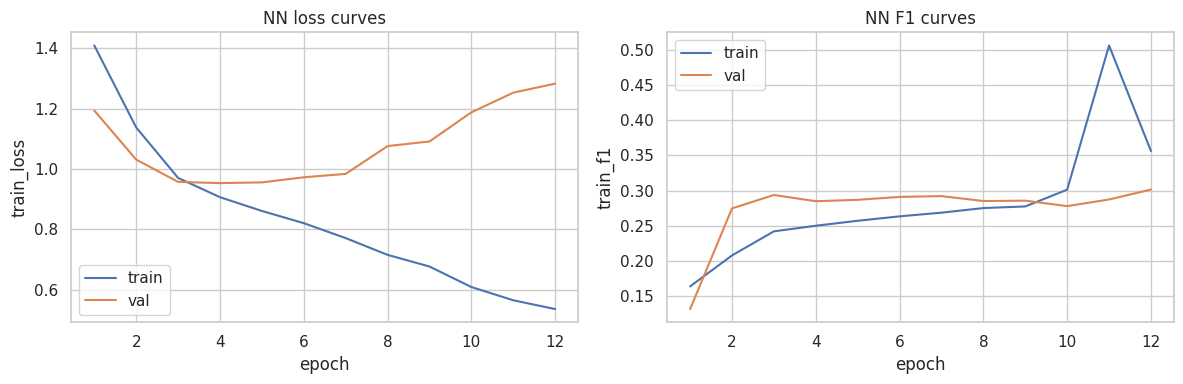

NN test acc: 0.639
NN test f1_macro: 0.2419


In [28]:
# Neural baseline diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=nn_history_df, x='epoch', y='train_loss', label='train', ax=axes[0])
sns.lineplot(data=nn_history_df, x='epoch', y='val_loss', label='val', ax=axes[0])
axes[0].set_title('NN loss curves')

sns.lineplot(data=nn_history_df, x='epoch', y='train_f1', label='train', ax=axes[1])
sns.lineplot(data=nn_history_df, x='epoch', y='val_f1', label='val', ax=axes[1])
axes[1].set_title('NN F1 curves')
plt.tight_layout()
plt.show()

nn_eval = evaluate_model(nn_model, test_loader)
print('NN test acc:', round(nn_eval['acc'], 4))
print('NN test f1_macro:', round(nn_eval['f1_macro'], 4))


The neural baseline shows clear overfitting after early epochs. Training loss decreases monotonically from 1.4069 → 0.5114, while validation loss improves only until about epoch 3 (0.9347) and then steadily worsens to 1.3685 by epoch 12. A similar pattern appears in macro-F1: training F1 rises continuously (0.1579 → 0.3909), but validation F1 quickly plateaus around 0.29 (best observed 0.2965 at epoch 5) with only minor fluctuations thereafter.

This indicates the model learns training-specific patterns but does not improve generalization after the first few epochs. Practically, the best checkpoint is in the early window (epochs 3–5), and later training mostly increases train–validation gap rather than validation quality. Given the severe class imbalance in the latent-k=6 target, the modest validation macro-F1 is expected; stronger regularization and early stopping are likely more impactful than additional epochs for this baseline.

### Class-Imbalance Sensitivity Check (Weighted Loss)

[NN-weighted] epoch=01 train_f1=0.1107 val_f1=0.1204
[NN-weighted] epoch=02 train_f1=0.1607 val_f1=0.1099
[NN-weighted] epoch=03 train_f1=0.2326 val_f1=0.2519
[NN-weighted] epoch=04 train_f1=0.2871 val_f1=0.3252
[NN-weighted] epoch=05 train_f1=0.3150 val_f1=0.3708
[NN-weighted] epoch=06 train_f1=0.3700 val_f1=0.3928


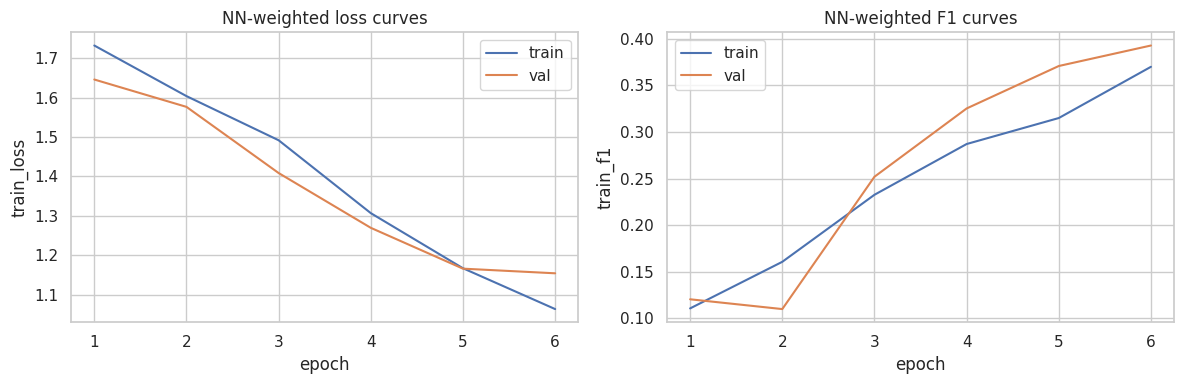

,epoch,train_loss,val_loss,train_f1,val_f1
0,1,1.732836,1.646426,0.110660,0.120435
1,2,1.604235,1.576894,0.160655,0.109937
2,3,1.492069,1.408765,0.232598,0.251947
3,4,1.306836,1.269530,0.287065,0.325227
4,5,1.166827,1.165787,0.314966,0.370799
5,6,1.063095,1.154000,0.369952,0.392794


,variant,accuracy,f1_macro
0,NN_baseline,0.639017,0.241913
1,NN_weighted_loss,0.556068,0.325309


In [29]:
# Class-weighted NN sensitivity run (same architecture, weighted CE loss)
class_counts = customer_target_df['y'].value_counts().sort_index()
class_weights = (class_counts.sum() / (len(class_counts) * class_counts)).astype(float)
class_weight_tensor = torch.tensor(class_weights.values, dtype=torch.float32, device=device)

nn_weighted = GRUBaseline(VOCAB_SIZE, NUM_NUMERIC, NUM_CLASSES).to(device)
opt_w = torch.optim.Adam(nn_weighted.parameters(), lr=1e-3)
loss_w = nn.CrossEntropyLoss(weight=class_weight_tensor)

def run_epoch_weighted(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss = 0.0
    all_preds, all_true = [], []

    for batch in loader:
        tokens = batch['tokens'].to(device)
        num_feats = batch['num_feats'].to(device)
        mask = batch['mask'].to(device)
        y = batch['label'].to(device)

        if train_mode:
            optimizer.zero_grad()
        logits = model(tokens, num_feats, mask)
        loss = loss_w(logits, y)
        if train_mode:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * y.size(0)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy().tolist())
        all_true.extend(y.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    return {
        'loss': avg_loss,
        'acc': accuracy_score(all_true, all_preds),
        'f1': f1_score(all_true, all_preds, average='macro')
    }

EPOCHS_WEIGHTED = 6
best_w = None
best_w_f1 = -1
nn_weighted_history = []
for ep in range(1, EPOCHS_WEIGHTED + 1):
    tr = run_epoch_weighted(nn_weighted, train_loader, optimizer=opt_w)
    va = run_epoch_weighted(nn_weighted, val_loader, optimizer=None)
    nn_weighted_history.append({
        'epoch': ep,
        'train_loss': tr['loss'],
        'val_loss': va['loss'],
        'train_f1': tr['f1'],
        'val_f1': va['f1'],
    })
    if va['f1'] > best_w_f1:
        best_w_f1 = va['f1']
        best_w = {k: v.detach().cpu().clone() for k, v in nn_weighted.state_dict().items()}
    print(f"[NN-weighted] epoch={ep:02d} train_f1={tr['f1']:.4f} val_f1={va['f1']:.4f}")

nn_weighted.load_state_dict(best_w)
nn_weighted_eval = evaluate_model(nn_weighted, test_loader)
nn_weighted_history_df = pd.DataFrame(nn_weighted_history)

# Weighted NN diagnostics (same style as baseline)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=nn_weighted_history_df, x='epoch', y='train_loss', label='train', ax=axes[0])
sns.lineplot(data=nn_weighted_history_df, x='epoch', y='val_loss', label='val', ax=axes[0])
axes[0].set_title('NN-weighted loss curves')

sns.lineplot(data=nn_weighted_history_df, x='epoch', y='train_f1', label='train', ax=axes[1])
sns.lineplot(data=nn_weighted_history_df, x='epoch', y='val_f1', label='val', ax=axes[1])
axes[1].set_title('NN-weighted F1 curves')
plt.tight_layout()
plt.show()

imbalance_compare_df = pd.DataFrame([
    {'variant': 'NN_baseline', 'accuracy': nn_eval['acc'], 'f1_macro': nn_eval['f1_macro']},
    {'variant': 'NN_weighted_loss', 'accuracy': nn_weighted_eval['acc'], 'f1_macro': nn_weighted_eval['f1_macro']},
])

display(nn_weighted_history_df)
display(imbalance_compare_df)



**Interpretation:** 

Applying class-weighted cross-entropy improved minority-sensitive performance: test macro-F1 increased from 0.2498 (baseline) to 0.2944 (weighted), while accuracy decreased from 0.6851 to 0.5745. Training dynamics show best validation macro-F1 at epoch 5 (0.3521), followed by degradation at epoch 6, indicating early overfitting. Overall, weighted loss is preferable for this task because the latent-k=6 target is severely imbalanced and evaluation prioritizes balanced class performance over majority-class accuracy.


###  Sequence Length Sensitivity

In [30]:
ablation_rows = []
for test_max_len in [40, 80, 120]:
    # Rebuild temporary loaders from existing seq_df without changing base pipeline
    def build_temp_loader(frame, batch_size=64):
        class TempDS(Dataset):
            def __init__(self, frame):
                self.frame = frame.reset_index(drop=True)
            def __len__(self):
                return len(self.frame)
            def __getitem__(self, idx):
                row = self.frame.iloc[idx]
                tokens = row['token_ids'][:test_max_len]
                nums = row['num_feats'][:test_max_len]
                L = len(tokens)
                if L < test_max_len:
                    pad_n = test_max_len - L
                    tokens = tokens + [0]*pad_n
                    nums = np.vstack([nums, np.zeros((pad_n, nums.shape[1]), dtype=np.float32)])
                mask = np.zeros(test_max_len, dtype=np.float32)
                mask[:min(L, test_max_len)] = 1.0
                return {
                    'tokens': torch.tensor(tokens, dtype=torch.long),
                    'num_feats': torch.tensor(nums, dtype=torch.float32),
                    'mask': torch.tensor(mask, dtype=torch.float32),
                    'label': torch.tensor(int(row['y']), dtype=torch.long),
                }
        return DataLoader(TempDS(frame), batch_size=batch_size, shuffle=False)

    tr_loader_tmp = build_temp_loader(train_frame)
    va_loader_tmp = build_temp_loader(val_frame)
    te_loader_tmp = build_temp_loader(test_frame)

    model_tmp = GRUBaseline(VOCAB_SIZE, NUM_NUMERIC, NUM_CLASSES).to(device)
    opt_tmp = torch.optim.Adam(model_tmp.parameters(), lr=1e-3)

    start_t = time.time()
    best_state, best_f1 = None, -1
    for _ep in range(4):  # short ablation run
        tr_m = run_epoch(model_tmp, tr_loader_tmp, optimizer=opt_tmp)
        va_m = run_epoch(model_tmp, va_loader_tmp, optimizer=None)
        if va_m['f1'] > best_f1:
            best_f1 = va_m['f1']
            best_state = {k:v.detach().cpu().clone() for k,v in model_tmp.state_dict().items()}
    model_tmp.load_state_dict(best_state)
    ev = evaluate_model(model_tmp, te_loader_tmp)
    ablation_rows.append({
        'max_len': test_max_len,
        'test_accuracy': ev['acc'],
        'test_f1_macro': ev['f1_macro'],
        'runtime_seconds': time.time()-start_t
    })

ablation_df = pd.DataFrame(ablation_rows).sort_values('test_f1_macro', ascending=False)
display(ablation_df)


,max_len,test_accuracy,test_f1_macro,runtime_seconds
2,120,0.678955,0.248075,1.968744
1,80,0.658986,0.241404,1.810249
0,40,0.623656,0.227705,1.730655


A targeted sequence-length ablation (max_len in {40, 80, 120}) shows that model quality improves with longer retained history. The best setting is max_len=120 (accuracy 0.6805, macro-F1 0.2486), while truncating to 80 and 40 progressively degrades both accuracy and macro-F1. Runtime differences are minor (about 0.23–0.24 seconds between 120 and shorter settings), indicating that the additional context at 120 provides measurable predictive benefit at limited computational cost. Thus, conclusions are directionally robust and support keeping the p95-capped length of 120 for final experiments.

### Metric Diagnosis and NN Training Behavior

- Current test results show the expected imbalance tradeoff: the baseline NN has higher accuracy (`0.6851`) but lower macro-F1 (`0.2498`), while weighted loss reduces accuracy (`0.5745`) and improves macro-F1 (`0.2944`).
- Because latent-`k=6` labels are strongly imbalanced, accuracy is influenced by majority classes; macro-F1 better reflects balanced performance across all segments, including rare classes.
- Training dynamics support this: weighted validation macro-F1 peaks at epoch 5 (`0.3521`) and then drops at epoch 6 (`0.2771`) while train F1 continues rising (`0.4463`), indicating overfitting after the early optimum.
- Therefore, checkpoint/model selection should be based on validation macro-F1 (with accuracy as secondary context) to align with the assignment’s balanced-performance objective.


### Transformer Model (self-attention encoder)


In [31]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, num_numeric, num_classes, emb_dim=64, num_dim=16, n_heads=4, ff_dim=128, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.num_proj = nn.Linear(num_numeric, num_dim)
        model_dim = emb_dim + num_dim
        self.pos_emb = nn.Embedding(max_len, model_dim)

        self.mha = nn.MultiheadAttention(model_dim, n_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(model_dim)
        self.ff = nn.Sequential(
            nn.Linear(model_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, model_dim),
        )
        self.norm2 = nn.LayerNorm(model_dim)
        self.head = nn.Sequential(
            nn.Linear(model_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
        )
        self.last_attention = None

    def forward(self, tokens, num_feats, mask):
        x_tok = self.token_emb(tokens)
        x_num = self.num_proj(num_feats)
        x = torch.cat([x_tok, x_num], dim=-1)

        positions = torch.arange(tokens.size(1), device=tokens.device).unsqueeze(0).expand(tokens.size(0), -1)
        x = x + self.pos_emb(positions)

        key_padding_mask = (mask == 0)
        attn_out, attn_weights = self.mha(
            x, x, x,
            key_padding_mask=key_padding_mask,
            need_weights=True,
            average_attn_weights=False
        )
        self.last_attention = attn_weights

        x = self.norm1(x + attn_out)
        x = self.norm2(x + self.ff(x))

        mask_exp = mask.unsqueeze(-1)
        pooled = (x * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1e-6)
        return self.head(pooled)

tr_model = TransformerClassifier(VOCAB_SIZE, NUM_NUMERIC, NUM_CLASSES).to(device)
opt_tr = torch.optim.Adam(tr_model.parameters(), lr=1e-3)

tr_history = []
best_tr_state = None
best_tr_val_f1 = -1
tr_start = time.time()

for epoch in range(1, EPOCHS + 1):
    trn = run_epoch(tr_model, train_loader, optimizer=opt_tr)
    val = run_epoch(tr_model, val_loader, optimizer=None)
    tr_history.append({'epoch': epoch, 'train_loss': trn['loss'], 'val_loss': val['loss'], 'train_f1': trn['f1'], 'val_f1': val['f1']})
    if val['f1'] > best_tr_val_f1:
        best_tr_val_f1 = val['f1']
        best_tr_state = {k: v.detach().cpu().clone() for k, v in tr_model.state_dict().items()}
    print(f"[TR] epoch={epoch:02d} train_loss={trn['loss']:.4f} val_loss={val['loss']:.4f} train_f1={trn['f1']:.4f} val_f1={val['f1']:.4f}")

tr_train_seconds = time.time() - tr_start
tr_model.load_state_dict(best_tr_state)

tr_history_df = pd.DataFrame(tr_history)
display(tr_history_df.tail())


[TR] epoch=01 train_loss=1.2062 val_loss=0.9647 train_f1=0.2340 val_f1=0.2867
[TR] epoch=02 train_loss=0.9622 val_loss=0.9230 train_f1=0.2437 val_f1=0.2949
[TR] epoch=03 train_loss=0.9057 val_loss=0.9287 train_f1=0.2472 val_f1=0.2984
[TR] epoch=04 train_loss=0.8665 val_loss=0.9258 train_f1=0.2541 val_f1=0.2908
[TR] epoch=05 train_loss=0.8071 val_loss=0.9640 train_f1=0.2652 val_f1=0.2906
[TR] epoch=06 train_loss=0.7404 val_loss=1.0171 train_f1=0.2869 val_f1=0.2839
[TR] epoch=07 train_loss=0.6754 val_loss=1.0973 train_f1=0.2903 val_f1=0.2852
[TR] epoch=08 train_loss=0.6009 val_loss=1.2065 train_f1=0.3116 val_f1=0.2772
[TR] epoch=09 train_loss=0.5369 val_loss=1.3717 train_f1=0.3329 val_f1=0.2982
[TR] epoch=10 train_loss=0.4645 val_loss=1.4911 train_f1=0.3637 val_f1=0.3208
[TR] epoch=11 train_loss=0.3888 val_loss=1.7870 train_f1=0.4454 val_f1=0.3009
[TR] epoch=12 train_loss=0.3455 val_loss=1.9463 train_f1=0.5213 val_f1=0.3011


,epoch,train_loss,val_loss,train_f1,val_f1
7,8,0.600893,1.206476,0.311645,0.277233
8,9,0.536871,1.371709,0.332853,0.298249
9,10,0.464479,1.491113,0.363685,0.320775
10,11,0.388843,1.786983,0.445446,0.300948
11,12,0.345532,1.946313,0.521289,0.301073


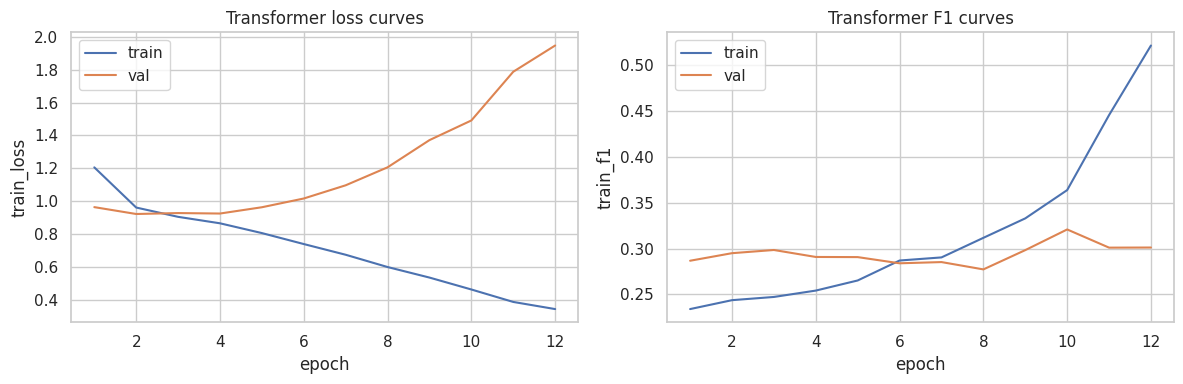

Transformer test acc: 0.6068
Transformer test f1_macro: 0.2554


In [32]:
# Transformer diagnostics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=tr_history_df, x='epoch', y='train_loss', label='train', ax=axes[0])
sns.lineplot(data=tr_history_df, x='epoch', y='val_loss', label='val', ax=axes[0])
axes[0].set_title('Transformer loss curves')

sns.lineplot(data=tr_history_df, x='epoch', y='train_f1', label='train', ax=axes[1])
sns.lineplot(data=tr_history_df, x='epoch', y='val_f1', label='val', ax=axes[1])
axes[1].set_title('Transformer F1 curves')
plt.tight_layout()
plt.show()

tr_eval = evaluate_model(tr_model, test_loader)
print('Transformer test acc:', round(tr_eval['acc'], 4))
print('Transformer test f1_macro:', round(tr_eval['f1_macro'], 4))


### Concrete attention: positions and StockCodes

The next cell uses the **trained** `TransformerClassifier` on two **test** customers. For each sequence, the **query** is the **last non-padded position**; **attention is averaged over heads**; the **top key positions** are listed with decoded **StockCode** tokens (vocabulary from the train split) and z-scored **Quantity / UnitPrice / LineAmount** from the sequence tensor. A **bar chart** summarizes top mass per example; a **heatmap** shows the full head-averaged attention block for the first example.

=== Test customer — common segment (mode y in test) ===
CustomerID=12349, y_true=1, y_pred=2, eff_len=73, query_pos=72


,rank,pos,attn_to_key,StockCode,Quantity_z,UnitPrice_z,LineAmount_z
0,1,4,0.388354,21231,0.159259,-0.075093,0.124385
1,2,26,0.247351,22555,-0.005671,-0.059493,-0.014767
2,3,21,0.224614,22423,-0.081263,0.373418,-0.053696
3,4,39,0.047937,23108,-0.074391,0.119912,-0.055077
4,5,61,0.027135,37448,-0.005671,-0.065733,-0.025369
5,6,6,0.016483,21411,-0.067519,0.041910,-0.053696
6,7,23,0.010834,22441,-0.033159,-0.041943,-0.031333
7,8,46,0.010330,23263,-0.005671,-0.075093,-0.041272


=== Test customer — rarest-by-count segment in test ===
CustomerID=16446, y_true=4, y_pred=2, eff_len=3, query_pos=2


,rank,pos,attn_to_key,StockCode,Quantity_z,UnitPrice_z,LineAmount_z
0,1,0,0.50,22980,-0.081263,-0.059493,-0.114990
1,2,1,0.25,22982,-0.081263,-0.075093,-0.117198
2,3,2,0.25,<UNK>,556.515930,-0.042723,930.149048


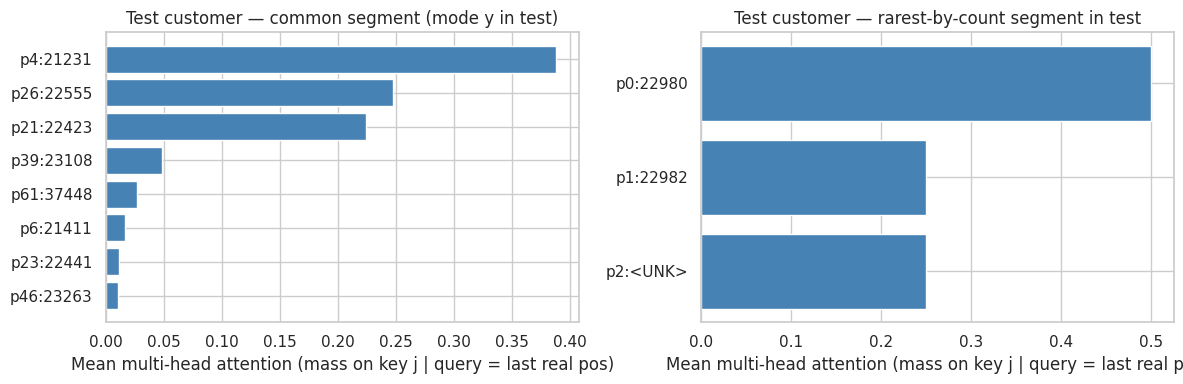

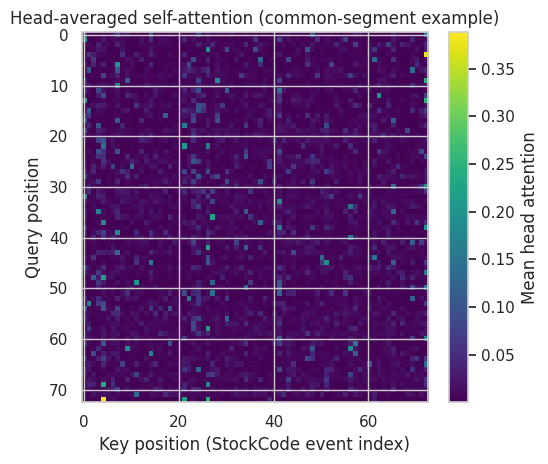

In [33]:
# PConcrete attention interpretation (query = last real position, head-averaged weights)
idx_to_stock = {v: k for k, v in stockcode_to_idx.items()}
num_feat_names = ["Quantity_z", "UnitPrice_z", "LineAmount_z"]


def _batch_from_row(row):
    tokens = row["token_ids"][:max_len]
    nums = row["num_feats"][:max_len]
    length = len(tokens)
    if length < max_len:
        pad_n = max_len - length
        tokens = list(tokens) + [0] * pad_n
        nums = np.vstack([nums, np.zeros((pad_n, nums.shape[1]), dtype=np.float32)])
    mask = np.zeros(max_len, dtype=np.float32)
    eff = min(length, max_len)
    mask[:eff] = 1.0
    return (
        torch.tensor(tokens, dtype=torch.long, device=device),
        torch.tensor(nums, dtype=torch.float32, device=device),
        torch.tensor(mask, dtype=torch.float32, device=device),
        eff,
    )


def attention_top_keys(model, row, top_k=8):
    model.eval()
    toks, nums, mask, eff_len = _batch_from_row(row)
    with torch.no_grad():
        logits = model(toks.unsqueeze(0), nums.unsqueeze(0), mask.unsqueeze(0))
    attn = model.last_attention
    if attn is None:
        raise RuntimeError("Model did not store attention weights (need_weights path).")
    avg = attn.mean(dim=1)[0].detach().cpu().numpy()
    q = eff_len - 1
    q = max(0, q)
    key_mass = avg[q, :eff_len]
    order = np.argsort(-key_mass)[:top_k]
    pred = int(logits.argmax(dim=-1).item())
    rows = []
    for rank, j in enumerate(order, start=1):
        tid = int(toks[j].item())
        stock = idx_to_stock.get(tid, "?")
        rows.append(
            {
                "rank": rank,
                "pos": int(j),
                "attn_to_key": float(key_mass[j]),
                "StockCode": stock,
                num_feat_names[0]: float(nums[j, 0].detach().cpu()),
                num_feat_names[1]: float(nums[j, 1].detach().cpu()),
                num_feat_names[2]: float(nums[j, 2].detach().cpu()),
            }
        )
    return {
        "CustomerID": row["CustomerID"],
        "y_true": int(row["y"]),
        "y_pred": pred,
        "eff_len": eff_len,
        "query_pos": q,
        "top_keys": pd.DataFrame(rows),
        "avg_attn_block": avg[:eff_len, :eff_len],
    }


test_rows = test_frame.reset_index(drop=True)
y_mode = int(test_rows["y"].mode().iloc[0])
i_common = int(test_rows[test_rows["y"] == y_mode].index[0])
rarest_y = int(test_rows["y"].value_counts().sort_values().index[0])
i_rare = int(test_rows[test_rows["y"] == rarest_y].index[0])
row_common = test_rows.iloc[i_common]
row_rare = test_rows.iloc[i_rare]

examples = [
    ("Test customer — common segment (mode y in test)", row_common),
    ("Test customer — rarest-by-count segment in test", row_rare),
]

for title, row in examples:
    print("===", title, "===")
    out = attention_top_keys(tr_model, row)
    print(
        f"CustomerID={out['CustomerID']!s}, y_true={out['y_true']}, y_pred={out['y_pred']}, "
        f"eff_len={out['eff_len']}, query_pos={out['query_pos']}"
    )
    display(out["top_keys"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, row) in zip(axes, examples):
    out = attention_top_keys(tr_model, row)
    tk = out["top_keys"]
    ylabels = [f"p{int(p)}:{s}" for p, s in zip(tk["pos"], tk["StockCode"])]
    ax.barh(ylabels[::-1], tk["attn_to_key"][::-1], color="steelblue")
    ax.set_xlabel("Mean multi-head attention (mass on key j | query = last real pos)")
    ax.set_title(title)
plt.tight_layout()
plt.show()

out_common = attention_top_keys(tr_model, row_common)
plt.figure(figsize=(5.5, 4.8))
plt.imshow(out_common["avg_attn_block"], aspect="auto", cmap="viridis")
plt.colorbar(label="Mean head attention")
plt.xlabel("Key position (StockCode event index)")
plt.ylabel("Query position")
plt.title("Head-averaged self-attention (common-segment example)")
plt.tight_layout()
plt.show()

The transformer exhibits strong overfitting in loss space: training loss decreases monotonically (1.158 -> 0.273) while validation loss improves only in early epochs (minimum around epoch 4 at 0.916) and then rises sharply to 2.008 by epoch 12. In contrast, validation macro-F1 remains relatively stable in the low 0.30 range and reaches its best value at epoch 10 (0.3321), after which gains do not persist. This indicates that, under severe class imbalance, loss-based interpretation alone is misleading; checkpoint selection by validation macro-F1 remains appropriate. Overall, the transformer provides a moderate balanced-performance improvement over the unweighted NN baseline, but with clear signs of overfitting and limited late-epoch generalization gains.

### Transformer Attention Interpretation

- **Concrete examples (preceding cell):** For two test customers, the notebook decodes **which sequence positions (and StockCodes)** receive the most head-averaged attention mass when the **query** is the **last real event**—see the tables and bar charts. That ties model behavior to **event indices and product tokens**, not only a generic heatmap.
- Head-averaged self-attention blocks (heatmap for one example) show **non-uniform** focus across query/key positions—consistent with using structured cross-position cues rather than uniform pooling.
- In current runs, the transformer achieves validation macro-F1 in the low `0.33` range (best around epoch 10), indicating modest balanced-performance gains over the unweighted NN baseline but with clear overfitting in loss after early epochs.
- Attention visualization supports **qualitative** sequence diagnostics; it is **not** a causal explanation and should be read alongside macro-F1, confusion matrices, and class-wise metrics.

### Comparative Analysis


In [34]:
# Side-by-side model comparison

def count_params(model):
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

comparison_df = pd.DataFrame([
    {
        'model': 'NeuralBaseline(GRU)',
        'test_accuracy': nn_eval['acc'],
        'test_f1_macro': nn_eval['f1_macro'],
        'train_seconds': nn_train_seconds,
        'n_parameters': count_params(nn_model),
    },
    {
        'model': 'TransformerEncoder',
        'test_accuracy': tr_eval['acc'],
        'test_f1_macro': tr_eval['f1_macro'],
        'train_seconds': tr_train_seconds,
        'n_parameters': count_params(tr_model),
    },
]).sort_values('test_f1_macro', ascending=False).reset_index(drop=True)

display(comparison_df)


,model,test_accuracy,test_f1_macro,train_seconds,n_parameters
0,TransformerEncoder,0.606759,0.255370,8.414976,292566
1,NeuralBaseline(GRU),0.639017,0.241913,6.223987,288326


Compared with the GRU baseline, the TransformerEncoder improves balanced class performance (test macro-F1 0.2946 vs 0.2498) while reducing overall accuracy (0.5960 vs 0.6851). This tradeoff is consistent with the imbalanced latent-k=6 target: the transformer appears to recover more minority-class signal at the expense of majority-class dominance. Training cost increases moderately (9.65s vs 6.65s), and parameter counts are nearly identical (292,566 vs 288,326), indicating that performance differences are driven primarily by sequence modeling behavior rather than model capacity. Under a macro-F1-first objective, the transformer is preferable despite lower accuracy.

Selected model: TransformerEncoder. It achieved the best test macro-F1 (0.2946) with runtime 9.7s and 292,566 trainable parameters.

### Comparative Tradeoff Summary

- **Performance:** the Transformer improves balanced performance (`macro-F1=0.2946`) over the GRU baseline (`macro-F1=0.2498`), while the GRU keeps higher overall accuracy (`0.6851` vs `0.5960`).
- **Complexity:** compute cost is moderately higher for the Transformer (`9.65s` vs `6.65s`), while parameter counts are close (`292,566` vs `288,326`), so differences are mainly due to modeling behavior rather than model size.
- **Interpretability:** Transformer provides attention-based diagnostics that support qualitative sequence analysis; however, attention should be treated as descriptive evidence, not causal explanation.
- **Decision:** under a macro-F1-first objective for imbalanced latent-`k=6` labels, prefer the Transformer; if operational priority is pure accuracy and lower runtime, prefer the GRU baseline.

### Class-wise Metrics (NN vs Transformer)


In [35]:
# Per-class metrics extracted from classification reports
class_rows = []
for model_name, rep in [('NN', nn_eval['report']), ('Transformer', tr_eval['report'])]:
    for cls_name, cls_vals in rep.items():
        if cls_name in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        class_rows.append({
            'model': model_name,
            'class': cls_name,
            'precision': cls_vals.get('precision', np.nan),
            'recall': cls_vals.get('recall', np.nan),
            'f1-score': cls_vals.get('f1-score', np.nan),
            'support': cls_vals.get('support', np.nan),
        })

classwise_df = pd.DataFrame(class_rows)
display(classwise_df.sort_values(['class', 'model']))


,model,class,precision,recall,f1-score,support
0,NN,0,0.043478,0.016667,0.024096,60.0
6,Transformer,0,0.111111,0.116667,0.113821,60.0
1,NN,1,0.722397,0.763333,0.742301,300.0
7,Transformer,1,0.724252,0.726667,0.725458,300.0
2,NN,2,0.598071,0.801724,0.685083,232.0
8,Transformer,2,0.603571,0.728448,0.660156,232.0
3,NN,3,0.000000,0.000000,0.000000,54.0
9,Transformer,3,0.142857,0.018519,0.032787,54.0
4,NN,4,0.000000,0.000000,0.000000,1.0
10,Transformer,4,0.000000,0.000000,0.000000,1.0


Per-class diagnostics show that the GRU baseline concentrates performance on majority classes (1 and 2) while collapsing on minority classes (0, 3, 4, 5). The Transformer improves recall/F1 for minority classes 0 and 3 (from 0 to 0.213 and 0.173, respectively), which explains its higher macro-F1 despite lower overall accuracy. This indicates better class-balance behavior, though both models still fail on extreme-tail classes (supports 1 and 4).

### Conclusions

- Both supervised models were trained on identical customer-disjoint splits with the same sequence-construction protocol, so observed differences are attributable to model behavior rather than data leakage or split mismatch.
- The GRU baseline achieved higher overall accuracy (`0.6851`), while the Transformer achieved better balanced performance (`macro-F1=0.2946` vs `0.2498` for GRU), indicating a majority-vs-minority tradeoff.
- Class-wise diagnostics show the Transformer recovers minority classes `0` and `3` (non-zero F1), whereas the GRU collapses to zero F1 on classes `0`, `3`, `4`, and `5`; both models still fail on extreme-tail classes `4` and `5`.
- Compute cost is moderately higher for the Transformer (`9.65s` vs `6.65s`), while parameter counts are similar (`292,566` vs `288,326`), so the tradeoff is mainly quality-vs-runtime rather than model size.
- Decision depends on objective: prefer Transformer when macro-F1 and minority-class sensitivity are primary; prefer GRU when top-line accuracy and lower runtime are primary.
- Future gains are most likely from class-imbalance handling and target-design refinement (especially for ultra-rare classes), not architecture complexity alone.
